# Spacing Statistics

## 1. Importing / Installing Packages

In [3]:
from __future__ import annotations # Enabling future annotations for type hinting

import os # Importing os module for operating system dependent functionality

import pandas as pd # Importing pandas package

# Set the maximum number of columns to display to None
pd.set_option('display.max_columns', None)

import numpy as np # Importing numpy package

import datetime

from typing import Dict, Tuple, List, Union, Optional, ClassVar, Any, Literal, Iterable # Importing specific types from typing module

from src.utils import DatabricksOdbcConnector # Importing DatabricksOdbcConnector class from database_manager module

from tqdm import tqdm # Importing tqdm for progress bar functionality

from joblib import Parallel, delayed # Importing Parallel and delayed for parallel processing

from matplotlib import pyplot as plt # Importing pyplot from matplotlib for plotting

from pyproj import Geod # Importing Geod class from pyproj for geodetic calculations

# Setting matplotlib to inline mode for Jupyter notebooks
%matplotlib inline

%config InlineBackend.figure_format = 'svg' # Configuring inline backend to use SVG format for figures

from src.well_data import WellDataLoader, GeoSurveyProcessor # Importing custom classes for well data management

from src.utils import reorder_columns # Importing utility function to reorder DataFrame columns


from dataclasses import dataclass # Importing dataclass decorator for creating data classes
from enum import Enum, auto # Importing Enum and auto for creating enumerations

## 2. Defining Functions

### 2.1. Defining Functions that is used in calculation for i-k pair dataframe and Spacing Stats

In [4]:
class AlignmentType(Enum):
    PARALLEL_LIKE = auto()
    OBLIQUE = auto()
    PERPENDICULAR = auto()
    MISALIGNED = auto()

@dataclass
class SpacingResult:
    # core identifiers
    well_i: Any
    well_k: Any

    # spacing metrics (same names you already emit)
    horizontal_dist: float
    horizontal_dist_median: float
    vertical_dist: float
    dist3d: float

    # overlap + LL (parallel-like; NaN otherwise)
    overlap_len_common_ft: float
    LL_i: float
    LL_k: float
    overlap_pct_i: float
    overlap_pct_k: float

    # diagnostics
    n_samples: int
    dy_p5: float
    angle_deg: float
    pair_alignment: str
    min_distance_ft: float       # for oblique/perp (NaN for parallel-like)
    mean_windowed_ft: float      # for oblique/perp (NaN for parallel-like)
    reject_reason: str

    # direction fields
    direction_axis: Optional[str]
    direction_to_k_from_i_axis: Optional[str]
    direction_axis_confidence: float
    direction_axis_distribution: str

    # drill directions
    drill_direction_i: str
    drill_direction_k: str

    # marker
    axis_forced: bool = True

@dataclass
class PairArtifacts:
    # Always useful
    Xi_utm: Optional[np.ndarray] = None
    Xk_utm: Optional[np.ndarray] = None
    Xi_if: Optional[np.ndarray] = None
    Xk_if: Optional[np.ndarray] = None
    dir_axis: Optional[str] = None
    has_latlon: bool = False

    # Parallel-like only
    overlap_band: Optional[Tuple[float, float]] = None
    Xi_clip: Optional[np.ndarray] = None
    Xk_clip: Optional[np.ndarray] = None
    xgrid: Optional[np.ndarray] = None
    yi: Optional[np.ndarray] = None
    yk: Optional[np.ndarray] = None
    Xi_utml: Optional[np.ndarray] = None
    Xk_utml: Optional[np.ndarray] = None
    theta_rose: Optional[np.ndarray] = None  # radians for polar plot

    # Oblique/Perp only
    s_targets: Optional[np.ndarray] = None
    Pi: Optional[np.ndarray] = None          # samples on i (UTM)
    Q: Optional[np.ndarray] = None           # nearest on k (UTM)
    d_series: Optional[np.ndarray] = None    # nearest distances

In [5]:
class WellSpacingCalculator:
    """
    Class for calculating well spacing metrics and directional relationships using
    3D lateral midpoint alignment and curvature-aware distances.
    Midpoints are projected in 2D space to remove lateral-length bias when calculating spacing.
    """

    # Class-level constant (shared, immutable-by-convention)
    _DIR4_LABELS: ClassVar[np.ndarray] = np.array(["N", "E", "S", "W"], dtype=object)

    def __init__(self, trajectories: Union[Dict[str, pd.DataFrame], pd.DataFrame]):
        if isinstance(trajectories, pd.DataFrame):
            if "uwi" not in trajectories.columns:
                raise ValueError("Trajectory DataFrame must contain 'uwi' column.")
            self._trajectory_df = trajectories.reset_index(drop=True)
            self.trajectories = {
                cid: group for cid, group in self._trajectory_df.groupby("uwi")
            }
        elif isinstance(trajectories, dict):
            self.trajectories = trajectories
            self._trajectory_df = pd.concat(
                trajectories.values(), keys=trajectories.keys()
            ).reset_index(drop=True)
        else:
            raise ValueError("Invalid type for trajectories. Must be DataFrame or Dict.")

    def _calculate_spacing_statistics(
        self,
        *,
        frac: float = 0.5,
        batch_size: int = 500_000,
        max_distance_miles: Optional[float] = 20.0,
        save_batches_dir: Optional[str] = None,
        use_interpolation: bool = False,
        # --- existing crossline knobs ---
        step_ft: int = 100,
        n_samples: Optional[int] = None,
        max_crossline_ft: Optional[float] = 2000.0,
        crossline_percentile: float = 5.0,
        ds_crossline_step_ft: int = 200,
        emit_rejected: bool = True,
        use_pca_axis: bool = True,
        # --- NEW: angle-based routing knobs ---
        theta_parallel_deg: float = 25.0,
        theta_perp_deg: float = 65.0,
        reject_misaligned: bool = False,
        # perpendicular optional smoothing
        use_windowed_mean: bool = False,
        window_ft: float = 300.0,
    ) -> Optional[pd.DataFrame]:
        """
        Compute spacing metrics for all well pairs, now with angle-aware routing:
        - parallel-like pairs: crossline |Δy(x)| over true i-frame overlap (your existing method)
        - oblique pairs: nearest-projection mean/median (walk along i, project to nearest point on k)
        - perpendicular pairs: closest approach (min distance) and optional ±window_ft mean
        """
        # Build the pair cache once (local frames + coarse arrays for precheck)
        self._build_pair_cache(use_pca_axis, ds_crossline_step_ft)

        # 1) Midpoints + drill directions (vertical distances remain midpoint-based)
        midpoint_df = self._compute_normalized_midpoints(frac=frac, use_interpolation=use_interpolation)
        drill_dirs = self._compute_drill_directions()
        midpoint_df["drill_direction"] = drill_dirs

        # 2) Arrays
        ids = midpoint_df.index.to_numpy()
        coords = midpoint_df[["x", "y", "tvd"]].to_numpy()
        lat_lon = midpoint_df[["latitude", "longitude"]].to_numpy()
        directions = midpoint_df["drill_direction"].to_numpy()

        # 3) Prefilter pairs (miles)
        if max_distance_miles is not None:
            lat = lat_lon[:, 0]; lon = lat_lon[:, 1]
            i_idx, k_idx = self._filter_close_pairs(lat, lon, max_distance_miles)
        else:
            i_idx, k_idx = self._get_pairwise_indices(ids)

        pairs = list(zip(i_idx, k_idx))
        batch_generator = list(self._batch_filtered_indices(pairs, batch_size=batch_size))
        n_batches = len(batch_generator)

        if save_batches_dir:
            os.makedirs(save_batches_dir, exist_ok=True)

        def process_and_save(batch_number: int, i_idx: np.ndarray, k_idx: np.ndarray):
            batch_df = self._process_batch(
                i_idx, k_idx, ids, coords, directions,
                step_ft=step_ft,
                n_samples=n_samples,
                max_crossline_ft=max_crossline_ft,
                crossline_percentile=crossline_percentile,
                ds_crossline_step_ft=ds_crossline_step_ft,
                emit_rejected=emit_rejected,
                use_pca_axis=use_pca_axis,
                theta_parallel_deg=theta_parallel_deg,
                theta_perp_deg=theta_perp_deg,
                reject_misaligned=reject_misaligned,
                use_windowed_mean=use_windowed_mean,
                window_ft=window_ft,
            )
            if save_batches_dir:
                filepath = os.path.join(save_batches_dir, f"spacing_batch_{batch_number:04d}.parquet")
                batch_df.to_parquet(filepath, index=False)
            return batch_df

        tqdm_kwargs = dict(
            desc="🚀 Calculating Spacing (Parallel)",
            dynamic_ncols=True,
            smoothing=0.3,
            bar_format="{desc}: |{bar:40}| {percentage:3.0f}% {n_fmt}/{total_fmt} [{elapsed}<{remaining}]",
            ascii="░▒█",
            leave=True,
        )

        results = Parallel(n_jobs=-1)(
            delayed(process_and_save)(batch_num, i_i, k_i)
            for batch_num, (i_i, k_i) in tqdm(enumerate(batch_generator), total=n_batches, **tqdm_kwargs)
        )

        if save_batches_dir:
            print(f"✅ All batches saved to {save_batches_dir}")
            return None
        else:
            return pd.concat(results, ignore_index=True)
    
    def _load_saved_batches(self, batch_folder: str) -> pd.DataFrame:
        """
        Load all saved spacing batch Parquet files from a folder and combine into a single DataFrame.

        Parameters
        ----------
        batch_folder : str
            Path to the folder where batch Parquet files are stored.

        Returns
        -------
        pd.DataFrame
            Combined spacing DataFrame.
        """
        if not os.path.isdir(batch_folder):
            raise FileNotFoundError(f"Batch folder '{batch_folder}' not found.")

        batch_files = sorted([
            os.path.join(batch_folder, f)
            for f in os.listdir(batch_folder)
            if f.endswith(".parquet")
        ])

        if not batch_files:
            raise ValueError(f"No Parquet files found in folder '{batch_folder}'.")

        print(f"🔍 Found {len(batch_files)} batch files. Loading and combining...")

        dfs = []
        for file in batch_files:
            dfs.append(pd.read_parquet(file))

        combined_df = pd.concat(dfs, ignore_index=True)
        print(f"✅ Loaded {len(combined_df):,} rows from all batches.")
        return combined_df

    def _filter_close_pairs(self, lat: np.ndarray, lon: np.ndarray, max_distance_miles: float = 20.0) -> Tuple[np.ndarray, np.ndarray]:

        lat1, lat2 = np.meshgrid(lat, lat, indexing="ij")
        lon1, lon2 = np.meshgrid(lon, lon, indexing="ij")

        delta_lat = np.abs(lat1 - lat2)
        delta_lon = np.abs(lon1 - lon2)

        miles_per_lat_degree = 69.0
        miles_per_lon_degree = 69.0 * np.cos(np.radians(lat))
        miles_per_lon_degree_matrix = np.add.outer(miles_per_lon_degree, miles_per_lon_degree) / 2.0

        rough_dist_miles = np.sqrt(
            (delta_lat * miles_per_lat_degree)**2 + (delta_lon * miles_per_lon_degree_matrix)**2
        )

        mask = (rough_dist_miles <= max_distance_miles) & (delta_lat + delta_lon > 0)
        i_idx, k_idx = np.where(mask)

        return i_idx, k_idx

    def _get_pairwise_indices(self, uwis: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate all valid pairwise (i, k) UWI combinations from an array of well IDs,
        excluding self-comparisons (i != k).

        Parameters
        ----------
        uwis : np.ndarray
            Array of unique well identifiers.

        Returns
        -------
        Tuple[np.ndarray, np.ndarray]
            Two 1D arrays of i and k UWIs representing all valid (i, k) pairs.
        """
        # Generate meshgrid of all possible UWI pairs
        n = len(uwis)
        i_idx, k_idx = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
            
        # Exclude self-comparisons (where i_uwi == k_uwi)
        valid_mask = i_idx != k_idx

        return i_idx[valid_mask], k_idx[valid_mask]

    def _batch_filtered_indices(self, pairs: List[Tuple[int, int]], batch_size: int = 1_000_000):
        """
        Vectorized batching of prefiltered well pairs.

        Parameters
        ----------
        pairs : List[Tuple[int, int]]
            List of (i_idx, k_idx) pairs.
        batch_size : int
            Number of pairs per batch.

        Yields
        ------
        Tuple[np.ndarray, np.ndarray]
            i_idx and k_idx arrays for each batch.
        """
        pairs_array = np.array(pairs)  # Convert list of tuples directly to 2D array (N, 2)
        n_pairs = pairs_array.shape[0]

        # Vectorized slicing
        split_indices = np.arange(0, n_pairs, batch_size)

        for start_idx in split_indices:
            end_idx = min(start_idx + batch_size, n_pairs)
            batch = pairs_array[start_idx:end_idx]
            yield batch[:, 0], batch[:, 1]

    def _compute_normalized_midpoints(self, frac: float = 0.5, use_interpolation: bool = True) -> pd.DataFrame:
        """
        Computes midpoints for each well either by interpolating along the well trajectory
        using MD-based fractional position or by averaging heel and toe coordinates.

        Parameters:
        -----------
        frac : float
            Fractional location along the lateral to compute the midpoint (0.0 to 1.0).
        use_interpolation : bool
            If True, uses curvature-aware interpolation along MD.
            If False, uses geometric midpoint between heel and toe.

        Returns:
        --------
        pd.DataFrame indexed by 'uwi', containing:
            ['x', 'y', 'tvd', 'latitude', 'longitude']
        """
        df = self._trajectory_df.copy()
        df = df.sort_values(["uwi", "md"]).reset_index(drop=True)

        if not use_interpolation:
            # Simple geometric midpoint (fast)
            heel_toe_df = (
                df.groupby("uwi")
                .agg(
                    heel_x=("x", "first"),
                    heel_y=("y", "first"),
                    heel_tvd=("tvd", "first"),
                    heel_lat=("latitude", "first"),
                    heel_lon=("longitude", "first"),
                    toe_x=("x", "last"),
                    toe_y=("y", "last"),
                    toe_tvd=("tvd", "last"),
                    toe_lat=("latitude", "last"),
                    toe_lon=("longitude", "last"),
                )
            )

            midpoint_df = pd.DataFrame({
                "x": (heel_toe_df["heel_x"] + heel_toe_df["toe_x"]) / 2,
                "y": (heel_toe_df["heel_y"] + heel_toe_df["toe_y"]) / 2,
                "tvd": (heel_toe_df["heel_tvd"] + heel_toe_df["toe_tvd"]) / 2,
                "latitude": (heel_toe_df["heel_lat"] + heel_toe_df["toe_lat"]) / 2,
                "longitude": (heel_toe_df["heel_lon"] + heel_toe_df["toe_lon"]) / 2,
            })
            midpoint_df.index.name = "uwi"
            return midpoint_df

        # Interpolated midpoint (MD-based)
        min_md = df.groupby("uwi")["md"].transform("min")
        max_md = df.groupby("uwi")["md"].transform("max")
        df["normalized_md"] = (df["md"] - min_md) / (max_md - min_md)

        df["row_index"] = df.groupby("uwi").cumcount()
        df["prev_idx"] = df.groupby("uwi")["normalized_md"].transform(lambda x: x.searchsorted(frac, side="right") - 1)
        df["next_idx"] = df["prev_idx"] + 1
        df["next_idx"] = np.minimum(df["next_idx"], df["row_index"].groupby(df["uwi"]).transform("max"))

        df_prev = df.groupby("uwi").apply(lambda g: g.loc[g["row_index"] == g["prev_idx"].iloc[0]]).reset_index(drop=True)
        df_next = df.groupby("uwi").apply(lambda g: g.loc[g["row_index"] == g["next_idx"].iloc[0]]).reset_index(drop=True)

        merged = pd.merge(df_prev, df_next, on="uwi", suffixes=("_prev", "_next"))

        delta = merged["normalized_md_next"] - merged["normalized_md_prev"]
        delta = delta.replace(0, np.nan)
        ratio = (frac - merged["normalized_md_prev"]) / delta

        midpoint_df = pd.DataFrame({
            "x": merged["x_prev"] + ratio * (merged["x_next"] - merged["x_prev"]),
            "y": merged["y_prev"] + ratio * (merged["y_next"] - merged["y_prev"]),
            "tvd": merged["tvd_prev"] + ratio * (merged["tvd_next"] - merged["tvd_prev"]),
            "latitude": merged["latitude_prev"] + ratio * (merged["latitude_next"] - merged["latitude_prev"]),
            "longitude": merged["longitude_prev"] + ratio * (merged["longitude_next"] - merged["longitude_prev"]),
        })
        midpoint_df["uwi"] = merged["uwi"]
        return midpoint_df.set_index("uwi")
    
    def _compute_drill_directions(self) -> pd.Series:
        median_azimuth = self._trajectory_df.groupby("uwi")["azimuth"].median()
        is_ew = ((median_azimuth >= 45) & (median_azimuth <= 135)) | ((median_azimuth >= 225) & (median_azimuth <= 315))
        return pd.Series(np.where(is_ew, "EW", "NS"), index=median_azimuth.index, name="drill_direction")

    def _axis_component_from_az(self, az_deg: np.ndarray, want_axis: str) -> np.ndarray:
        """
        Convert geodetic azimuth(s) (0°=N, 90°=E) to the signed component on a target axis.

        want_axis:
        - "EW" -> east-west component (sin), + = E, - = W
        - "NS" -> north-south component (cos), + = N, - = S
        """
        az = np.deg2rad(az_deg % 360.0)
        if want_axis == "EW":
            return np.sin(az)       # +E / -W
        elif want_axis == "NS":
            return np.cos(az)       # +N / -S
        else:
            raise ValueError("want_axis must be 'EW' or 'NS'")

    def _axis_label_from_component(self, comp: np.ndarray, want_axis: str,
                                deadband: float = 0.15, tie_tol: float = 0.05
    ) -> tuple[str, float, str]:
        """
        Turn signed axis components into a label + confidence + distribution string.

        - Ignores samples with |component| < deadband (neutral, avoids jitter).
        - Weighted vote by |component|; confidence = winner_weight / total_weight.
        - If near tie, fall back to the sign of the median of kept components.

        Returns:
        label: "E"/"W" if want_axis="EW", or "N"/"S" if want_axis="NS"
        confidence: float in [0,1]
        distribution: e.g. "E:0.83,W:0.17" or "N:0.91,S:0.09"
        """
        comp = np.asarray(comp, dtype=float)
        keep = np.abs(comp) >= float(deadband)
        if not keep.any():
            # Indeterminate; return low-confidence neutral toward positive side
            if want_axis == "EW":
                return "E", 0.0, "E:0.00,W:0.00"
            else:
                return "N", 0.0, "N:0.00,S:0.00"

        c = comp[keep]
        w_pos = float(np.abs(c[c > 0]).sum())
        w_neg = float(np.abs(c[c < 0]).sum())
        tot = w_pos + w_neg if (w_pos + w_neg) > 0 else 1.0

        # provisional winner
        if w_pos >= w_neg:
            winner, conf = ("E" if want_axis == "EW" else "N"), w_pos / tot
            loser = "W" if want_axis == "EW" else "S"
        else:
            winner, conf = ("W" if want_axis == "EW" else "S"), w_neg / tot
            loser = "E" if want_axis == "EW" else "N"

        # tie-break if very close
        if abs(w_pos - w_neg) / tot <= float(tie_tol):
            med = float(np.median(c))
            if med == 0.0:
                # keep original (essentially a tie)
                pass
            else:
                winner = ("E" if want_axis == "EW" else "N") if med > 0 else ("W" if want_axis == "EW" else "S")
                conf = max(w_pos, w_neg) / tot

        dist = (f"E:{w_pos/tot:.2f},W:{w_neg/tot:.2f}" if want_axis == "EW"
                else f"N:{w_pos/tot:.2f},S:{w_neg/tot:.2f}")
        return winner, conf, dist

    def _axis_constrained_direction_from_pairs(
        self,
        lat_i: np.ndarray, lon_i: np.ndarray,
        lat_k: np.ndarray, lon_k: np.ndarray,
        want_axis: str,
        *,
        deadband: float = 0.15,
        tie_tol: float = 0.05,
    ) -> tuple[str, float, str]:
        """
        Given arrays of matched i→k points (same length), compute geodetic azimuths and
        return axis-constrained label/conf/dist using the helpers above.
        """
        geod = Geod(ellps="WGS84")
        az12, _, _ = geod.inv(lon_i, lat_i, lon_k, lat_k)   # 0°=N, 90°=E
        comp = self._axis_component_from_az(az12, want_axis)
        return self._axis_label_from_component(comp, want_axis, deadband=deadband, tie_tol=tie_tol)

    def _axis_constrained_direction_over_overlap(
        self,
        Xi_seg: np.ndarray, Xk_seg: np.ndarray,
        lat_i_seg: np.ndarray, lon_i_seg: np.ndarray,
        lat_k_seg: np.ndarray, lon_k_seg: np.ndarray,
        want_axis: str,
        *,
        step_ft: int,
        n_samples: int | None,
        deadband: float = 0.15,
        tie_tol: float = 0.05,
    ) -> tuple[str, float, str]:
        """
        Use the same stationing you use for spacing over the clipped overlap and
        produce an axis-constrained direction label/conf/dist.
        """
        # choose sample count exactly as your spacing logic does
        si = self._arclength(Xi_seg); Li = si[-1]
        sk = self._arclength(Xk_seg); Lk = sk[-1]
        Lmin = max(min(Li, Lk), 1e-6)

        if n_samples is None:
            step = max(int(step_ft or 100), 1)
            n = max(int(np.floor(Lmin / step)) + 1, 2)
        else:
            n = max(int(n_samples), 2)
        t = np.linspace(0.0, 1.0, n)

        # interpolate lat/lon by arclength on both segments
        lat_i = self._interp_attr_by_arclength(Xi_seg, lat_i_seg, t * Li)
        lon_i = self._interp_attr_by_arclength(Xi_seg, lon_i_seg, t * Li)
        lat_k = self._interp_attr_by_arclength(Xk_seg, lat_k_seg, t * Lk)
        lon_k = self._interp_attr_by_arclength(Xk_seg, lon_k_seg, t * Lk)

        return self._axis_constrained_direction_from_pairs(
            lat_i, lon_i, lat_k, lon_k, want_axis,
            deadband=deadband, tie_tol=tie_tol
        )

    def _build_pair_cache(
        self,
        use_pca_axis: bool,
        ds_crossline_step_ft: int,
        ds_min_points: int = 16,
        ds_max_points: int = 64,
    ):
        """
        Precompute per-well:
        - origin, ex, ey (local frame metadata)
        - coarse resample XY (same length across wells) for vectorized cross-line precheck
        """
        # Compute each well's lateral length to pick a *global* coarse point count
        lengths = {}
        for uwi, df in self.trajectories.items():
            XY = df.sort_values("md")[["x","y"]].to_numpy()
            d = np.hypot(np.diff(XY[:,0]), np.diff(XY[:,1]))
            lengths[uwi] = float(d.sum())

        # Choose a *single* coarse count using median length / step, then clamp
        median_len = np.median(list(lengths.values())) if lengths else 3000.0
        m_guess = int(np.ceil(max(median_len, 1.0) / max(ds_crossline_step_ft, 1))) + 1
        M_ds = int(np.clip(m_guess, ds_min_points, ds_max_points))

        cache = {
            "origin": {},
            "ex": {},
            "ey": {},
            "XY_coarse": {},
            "M_ds": M_ds,
            "use_pca_axis": use_pca_axis,
            "LL": lengths      # <-- ADD: per-well lateral length in feet
        }

        for uwi, df in self.trajectories.items():
            df = df.sort_values("md")
            XY = df[["x","y"]].to_numpy()

            # local frame metadata
            pts = XY
            heel, toe = pts[0], pts[-1]
            origin = heel.copy()
            if use_pca_axis:
                C = pts - pts.mean(0)
                _, _, Vt = np.linalg.svd(C, full_matrices=False)
                ex = Vt[0]
                if np.dot(ex, toe - heel) < 0:
                    ex = -ex
            else:
                v = toe - heel
                ex = v / (np.linalg.norm(v) + 1e-12)
            ey = np.array([-ex[1], ex[0]])

            cache["origin"][uwi] = origin
            cache["ex"][uwi] = ex
            cache["ey"][uwi] = ey

            # coarse resample to common length M_ds by arclength
            d = np.hypot(np.diff(XY[:,0]), np.diff(XY[:,1]))
            s = np.concatenate([[0.0], np.cumsum(d)])
            L = s[-1] if s.size else 0.0
            if L <= 0.0:
                XYc = np.repeat(XY[:1], M_ds, axis=0)
            else:
                t = np.linspace(0.0, 1.0, M_ds)
                sx = np.interp(t*L, s, XY[:,0])
                sy = np.interp(t*L, s, XY[:,1])
                XYc = np.column_stack([sx, sy])

            cache["XY_coarse"][uwi] = XYc

        self._paircache = cache

    def _build_local_frame_from_i(self, df_i: pd.DataFrame, use_pca_axis: bool = True
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Build well_i's local frame from its UTM x,y points.
        origin: heel (first by MD); ex: along-lateral (PCA or heel→toe); ey: 90° CCW from ex.
        """
        pts = df_i.sort_values("md")[["x","y"]].to_numpy()
        heel, toe = pts[0], pts[-1]
        origin = heel.copy()

        if use_pca_axis:
            C = pts - pts.mean(0)
            _, _, Vt = np.linalg.svd(C, full_matrices=False)
            ex = Vt[0]
            if np.dot(ex, toe - heel) < 0:
                ex = -ex
        else:
            v = toe - heel
            ex = v / (np.linalg.norm(v) + 1e-12)

        ey = np.array([-ex[1], ex[0]])
        return origin, ex, ey
    
    def _project_xy_to_frame(self, df: pd.DataFrame, origin: np.ndarray, ex: np.ndarray, ey: np.ndarray
    ) -> np.ndarray:
        """Return Nx2 array of (x_local, y_local) from UTM x,y."""
        XY = df[["x","y"]].to_numpy()
        R = XY - origin
        return np.column_stack([R @ ex, R @ ey])
    
    def _clip_polyline_by_x_band(self, X: np.ndarray, band: Tuple[float, float]) -> np.ndarray:
        """
        Clip polyline X[:,0]=x, X[:,1]=y to x ∈ [x_lo, x_hi] and INSERT boundary
        intersection points by linear interpolation. Guarantees ≥2 points if the
        band intersects the polyline.
        """
        x_lo, x_hi = band
        x = X[:, 0]
        pts = []

        for j in range(len(X) - 1):
            x0, x1 = x[j], x[j + 1]
            P0, P1 = X[j], X[j + 1]

            seg_min, seg_max = (x0, x1) if x0 <= x1 else (x1, x0)
            if seg_max < x_lo or seg_min > x_hi:
                continue  # segment outside band

            # keep start if inside
            if x_lo <= x0 <= x_hi:
                pts.append(P0)

            # intersections with boundaries (strict crossing)
            for xb in (x_lo, x_hi):
                denom = (x1 - x0)
                if denom != 0.0 and (x0 - xb) * (x1 - xb) < 0.0:
                    t = (xb - x0) / denom
                    pts.append(P0 + t * (P1 - P0))

            # keep end if last seg and inside
            if j == len(X) - 2 and (x_lo <= x1 <= x_hi):
                pts.append(P1)

        if not pts:
            return np.empty((0, 2))

        P = np.vstack(pts)
        # drop exact duplicates while preserving order
        keep = np.ones(len(P), dtype=bool)
        if len(P) > 1:
            dup = np.all(np.isclose(np.diff(P, axis=0), 0.0, atol=1e-9), axis=1)
            keep[1:] = ~dup
        return P[keep]
    
    def _clip_polyline_with_latlon_by_x_band(
        self,
        X: np.ndarray,         # (N,2) local-frame (x,y)
        lat: np.ndarray,       # (N,)
        lon: np.ndarray,       # (N,)
        band: Tuple[float, float]
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Returns (X_clip, lat_clip, lon_clip), each with >=2 points if band intersects.
        Boundary points are linearly interpolated (for both XY and lat/lon).
        """
        x_lo, x_hi = band
        x = X[:, 0]
        pts_xy, pts_lat, pts_lon = [], [], []

        for j in range(len(X) - 1):
            x0, x1 = x[j], x[j + 1]
            P0, P1 = X[j], X[j + 1]
            lat0, lat1 = lat[j], lat[j + 1]
            lon0, lon1 = lon[j], lon[j + 1]

            seg_min, seg_max = (x0, x1) if x0 <= x1 else (x1, x0)
            if seg_max < x_lo or seg_min > x_hi:
                continue  # segment entirely outside band

            # keep start if inside
            if x_lo <= x0 <= x_hi:
                pts_xy.append(P0); pts_lat.append(lat0); pts_lon.append(lon0)

            # intersections with x_lo and x_hi (strict crossings)
            for xb in (x_lo, x_hi):
                denom = (x1 - x0)
                if denom != 0.0 and (x0 - xb) * (x1 - xb) < 0.0:
                    t = (xb - x0) / denom
                    pts_xy.append(P0 + t * (P1 - P0))
                    pts_lat.append(lat0 + t * (lat1 - lat0))
                    pts_lon.append(lon0 + t * (lon1 - lon0))

            # keep end if last seg and inside
            if j == len(X) - 2 and (x_lo <= x1 <= x_hi):
                pts_xy.append(P1); pts_lat.append(lat1); pts_lon.append(lon1)

        if not pts_xy:
            return np.empty((0, 2)), np.empty((0,)), np.empty((0,))

        XYc = np.vstack(pts_xy)
        latc = np.asarray(pts_lat, dtype=float)
        lonc = np.asarray(pts_lon, dtype=float)

        # drop adjacent duplicates (numeric noise)
        if len(XYc) > 1:
            dup = np.all(np.isclose(np.diff(XYc, axis=0), 0.0, atol=1e-9), axis=1)
            keep = np.ones(len(XYc), dtype=bool); keep[1:] = ~dup
            XYc, latc, lonc = XYc[keep], latc[keep], lonc[keep]
        return XYc, latc, lonc
    
    def _interp_y_of_x(self, X: np.ndarray, x_targets: np.ndarray) -> np.ndarray:
        """
        Piecewise-linear interpolation of y(x) on a 2D polyline X[:,0]=x, X[:,1]=y.
        Assumes x is roughly monotonic *within the clipped overlap*.
        Handles duplicate x by collapsing them.
        """
        x = X[:, 0]; y = X[:, 1]
        order = np.argsort(x)
        x_sorted = x[order]; y_sorted = y[order]
        keep = np.concatenate([[True], np.diff(x_sorted) > 1e-9])  # drop duplicate x
        x_sorted = x_sorted[keep]; y_sorted = y_sorted[keep]

        if x_sorted.size == 1:
            # Degenerate segment: constant y
            return np.full_like(x_targets, y_sorted[0], dtype=float)

        x_lo, x_hi = x_sorted[0], x_sorted[-1]
        xq = np.clip(x_targets, x_lo, x_hi)
        return np.interp(xq, x_sorted, y_sorted)

    def _nearest_distances_to_polyline(
        self, P: np.ndarray, X: np.ndarray
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Vectorized nearest point from many points P (n,2) to a polyline X (m,2).
        Returns (d, j, t) where:
        d: (n,) distances,
        j: (n,) segment indices (X[j] -> X[j+1]),
        t: (n,) segment parameters in [0,1].
        """
        A = X[:-1]                  # (m-1,2)
        B = X[1:]                   # (m-1,2)
        AB = B - A                  # (m-1,2)

        AP = P[:, None, :] - A[None, :, :]              # (n,m-1,2)
        denom = (AB[None, :, 0]**2 + AB[None, :, 1]**2) # (1,m-1)
        denom = np.where(denom == 0.0, 1e-12, denom)

        t = (AP[..., 0]*AB[None, :, 0] + AP[..., 1]*AB[None, :, 1]) / denom  # (n,m-1)
        t = np.clip(t, 0.0, 1.0)

        Q = A[None, :, :] + t[..., None] * AB[None, :, :]  # (n,m-1,2)
        diff = Q - P[:, None, :]
        d2 = diff[..., 0]**2 + diff[..., 1]**2             # (n,m-1)

        j = np.argmin(d2, axis=1)                          # (n,)
        d = np.sqrt(d2[np.arange(P.shape[0]), j])
        t_sel = t[np.arange(P.shape[0]), j]
        return d, j, t_sel

    def _crossline_spacing_from_overlap(
        self,
        Xi_seg: np.ndarray, Xk_seg: np.ndarray,
        *,
        step_ft: int,
        n_samples: Optional[int] = None,
    ) -> Tuple[float, int, float]:
        """
        Map-style crossline spacing:
        - Build a common x-grid across the TRUE overlap band (in i-frame).
        - Interpolate y_i(x) and y_k(x).
        - Return mean(|Δy(x)|), number of stations, and overlap length in x.

        Returns: (cross_mean, n_stations, overlap_len_x)
        """
        if Xi_seg.size == 0 or Xk_seg.size == 0:
            return float("nan"), 0, 0.0

        xi_min, xi_max = float(Xi_seg[:,0].min()), float(Xi_seg[:,0].max())
        xk_min, xk_max = float(Xk_seg[:,0].min()), float(Xk_seg[:,0].max())
        x_lo, x_hi = max(xi_min, xk_min), min(xi_max, xk_max)
        if not (x_hi > x_lo):
            return float("nan"), 0, 0.0

        step = max(int(step_ft or 100), 1)
        n = max(int(np.floor((x_hi - x_lo)/step)) + 1, 2)  # works even if overlap < step
        xgrid = np.linspace(x_lo, x_hi, n)

        yi = self._interp_y_of_x(Xi_seg, xgrid)
        yk = self._interp_y_of_x(Xk_seg, xgrid)
        dy = np.abs(yk - yi)

        cross_mean = float(dy.mean())
        return cross_mean, int(n), float(x_hi - x_lo)
    
    def _crossline_spacing_median_from_overlap(
        self,
        Xi_seg: np.ndarray, Xk_seg: np.ndarray,
        *,
        step_ft: int,
        n_samples: Optional[int] = None,
    ) -> Tuple[float, int, float]:
        """
        Map-style crossline spacing (median):
        - Build a common x-grid across the TRUE overlap band (in i-frame).
        - Interpolate y_i(x) and y_k(x).
        - Return median(|Δy(x)|), number of stations, and overlap length in x.

        Returns: (cross_median, n_stations, overlap_len_x)
        """
        if Xi_seg.size == 0 or Xk_seg.size == 0:
            return float("nan"), 0, 0.0

        xi_min, xi_max = float(Xi_seg[:,0].min()), float(Xi_seg[:,0].max())
        xk_min, xk_max = float(Xk_seg[:,0].min()), float(Xk_seg[:,0].max())
        x_lo, x_hi = max(xi_min, xk_min), min(xi_max, xk_max)
        if not (x_hi > x_lo):
            return float("nan"), 0, 0.0

        step = max(int(step_ft or 100), 1)
        n = max(int(np.floor((x_hi - x_lo)/step)) + 1, 2)
        xgrid = np.linspace(x_lo, x_hi, n)

        yi = self._interp_y_of_x(Xi_seg, xgrid)
        yk = self._interp_y_of_x(Xk_seg, xgrid)
        dy = np.abs(yk - yi)

        cross_median = float(np.median(dy))
        return cross_median, int(n), float(x_hi - x_lo)
    
    def _spacing_from_overlap(
        self,
        Xi_seg: np.ndarray,           # (Ni,2)   i-frame clipped segment (x=along-i, y=crossline)
        Xk_seg: np.ndarray,           # (Nk,2)   i-frame clipped segment for k
        step_ft: Optional[int],
        n_samples: Optional[int],
    ) -> Tuple[float, int, float]:
        """
        Map-style crossline spacing over the clipped overlap.
        - Sample both segments by arclength (same # of samples).
        - Return mean |Δy| (crossline), the number of samples, and the length used (min of segment lengths).
        """
        # --- helpers used elsewhere in the class ---
        # self._arclength(X): cumulative length of 2D polyline
        # self._interp_by_arclength(X, s_targets): interpolate XY at arclengths

        si = self._arclength(Xi_seg); Li = float(si[-1]) if si.size else 0.0
        sk = self._arclength(Xk_seg); Lk = float(sk[-1]) if sk.size else 0.0

        # if either segment collapsed, treat as no usable overlap
        if Li <= 0.0 or Lk <= 0.0:
            return float("nan"), 0, 0.0

        # use the smaller physical length as the "overlap length" for reporting
        Lmin = min(Li, Lk)

        # choose sample count
        if n_samples is None:
            step = max(int(step_ft or 100), 1)
            n = max(int(np.floor(Lmin / step)) + 1, 2)   # at least 2 samples
        else:
            n = max(int(n_samples), 2)

        t = np.linspace(0.0, 1.0, n)
        # arclength sampling within each segment
        Pi = self._interp_by_arclength(Xi_seg, t * Li)
        Pk = self._interp_by_arclength(Xk_seg, t * Lk)

        # crossline difference is simply Δy in the i-frame
        dy = np.abs(Pk[:, 1] - Pi[:, 1])
        mean_crossline = float(np.nanmean(dy))

        return mean_crossline, int(n), float(Lmin)

    def _bin4_from_geod_az(self, az_deg_from_north: np.ndarray) -> np.ndarray:
        """
        Bin geodetic azimuths (0°=N, 90°=E, 180°=S, 270°=W) into 4 compass labels.
        Edges at 45°,135°,225°,315°. Returns array of {"N","E","S","W"}.
        """
        a = az_deg_from_north % 360.0
        idx = ((a + 45.0) // 90.0).astype(int) % 4  # 0:N, 1:E, 2:S, 3:W
        return self._DIR4_LABELS[idx]

    def _arclength(self, X: np.ndarray) -> np.ndarray:
        """Cumulative arclength of a 2D polyline X[:,0]=x, X[:,1]=y."""
        X = np.asarray(X)
        if X.size == 0 or len(X) < 2:
            return np.array([0.0], dtype=float)
        d = np.hypot(np.diff(X[:, 0]), np.diff(X[:, 1]))
        return np.concatenate([[0.0], np.cumsum(d)])

    def _interp_by_arclength(self, X: np.ndarray, s_targets: np.ndarray) -> np.ndarray:
        """
        Interpolate XY by arclength along polyline X at distances s_targets.
        Collapses zero-length segments to avoid duplicates.
        """
        X = np.asarray(X)
        s = self._arclength(X)
        # drop zero-length steps to keep interp well-defined
        keep = np.concatenate([[True], np.diff(s) > 1e-9])
        s, Xc = s[keep], X[keep]
        if s.size == 1:  # degenerate — return the single point repeated
            xi = np.full_like(s_targets, Xc[0, 0], dtype=float)
            yi = np.full_like(s_targets, Xc[0, 1], dtype=float)
        else:
            xi = np.interp(s_targets, s, Xc[:, 0])
            yi = np.interp(s_targets, s, Xc[:, 1])
        return np.column_stack([xi, yi])

    def _interp_attr_by_arclength(self, X: np.ndarray, attr: np.ndarray, s_targets: np.ndarray) -> np.ndarray:
        """
        Interpolate a 1D attribute sampled along polyline X at distances s_targets.
        """
        X = np.asarray(X); attr = np.asarray(attr)
        s = self._arclength(X)
        keep = np.concatenate([[True], np.diff(s) > 1e-9])
        s, a = s[keep], attr[keep]
        if s.size == 1:
            return np.full_like(s_targets, a[0], dtype=float)
        return np.interp(s_targets, s, a)

    def _modal_direction_geodetic_over_overlap(
        self,
        Xi_seg: np.ndarray, Xk_seg: np.ndarray,          # local XY clipped segments
        lat_i_seg: np.ndarray, lon_i_seg: np.ndarray,    # clipped lat/lon for i
        lat_k_seg: np.ndarray, lon_k_seg: np.ndarray,    # clipped lat/lon for k
        step_ft: Optional[int], n_samples: Optional[int]
    ) -> Tuple[str, float, str]:
        """
        Returns (modal_direction_8way, confidence, distribution_string)
        using geodetic bearings at the same sample grid as spacing.
        """
        # Sample count (match spacing logic)
        si = self._arclength(Xi_seg); Li = si[-1]
        sk = self._arclength(Xk_seg); Lk = sk[-1]
        Lmin = max(min(Li, Lk), 1e-6)

        if n_samples is None:
            step = max(int(step_ft or 100), 1)
            n = max(int(np.floor(Lmin / step)) + 1, 2)
        else:
            n = max(int(n_samples), 2)
        t = np.linspace(0.0, 1.0, n)

        # Interpolate lat/lon by arclength within each clipped segment
        s_i = t * Li
        s_k = t * Lk
        lat_i = self._interp_attr_by_arclength(Xi_seg, lat_i_seg, s_i)
        lon_i = self._interp_attr_by_arclength(Xi_seg, lon_i_seg, s_i)
        lat_k = self._interp_attr_by_arclength(Xk_seg, lat_k_seg, s_k)
        lon_k = self._interp_attr_by_arclength(Xk_seg, lon_k_seg, s_k)

        # Geodetic forward azimuth i→k at each sample
        geod = Geod(ellps="WGS84")
        az12, _, _ = geod.inv(lon_i, lat_i, lon_k, lat_k)  # degrees, vectorized

        # 8-way bins + aggregation
        labels = self._bin4_from_geod_az(az12)  # az12 is 0°=N CW from Geod.inv
        # mode + confidence
        uniq, counts = np.unique(labels, return_counts=True)
        best_idx = np.argmax(counts)
        mode = uniq[best_idx]
        conf = counts[best_idx] / float(n)

        # compact distribution string for QA
        parts = [f"{u}:{c/float(n):.2f}" for u, c in sorted(zip(uniq, counts), key=lambda z: -z[1])]
        dist_str = ",".join(parts)
        return mode, conf, dist_str
    
    def _classify_alignment(
        self,
        ex_i: np.ndarray,
        ex_k: np.ndarray,
        theta_parallel_deg: float,
        theta_perp_deg: float
    ) -> Tuple[AlignmentType, float]:
        # use absolute dot (direction-agnostic)
        dot_abs = float(np.abs(float(np.dot(ex_i, ex_k))))
        angle_deg = float(np.degrees(np.arccos(np.clip(dot_abs, -1.0, 1.0))))
        if angle_deg <= float(theta_parallel_deg):
            return AlignmentType.PARALLEL_LIKE, angle_deg
        if angle_deg >= float(theta_perp_deg):
            return AlignmentType.PERPENDICULAR, angle_deg
        return AlignmentType.OBLIQUE, angle_deg

    def _compute_pair_metrics_and_artifacts(
        self,
        uwi_i: Any,
        uwi_k: Any,
        *,
        step_ft: int,
        n_samples: Optional[int],
        max_crossline_ft: Optional[float],
        crossline_percentile: float,
        ds_crossline_step_ft: int,
        use_pca_axis: bool,
        theta_parallel_deg: float,
        theta_perp_deg: float,
        reject_misaligned: bool,
        use_windowed_mean: bool,
        window_ft: float,
        drill_direction_i: Optional[str] = None,
        drill_direction_k: Optional[str] = None,
        tvd_i: Optional[float] = None,
        tvd_k: Optional[float] = None,
        want_artifacts: bool = True,
    ) -> Tuple[SpacingResult, Optional[PairArtifacts]]:
        """
        Single source of truth for a pair's spacing + direction metrics.
        Reuses the class helpers you already have. If want_artifacts=True,
        returns all arrays the debug plots need; otherwise returns None for artifacts.
        """
        # Cache build if needed
        if getattr(self, "_paircache", None) is None or self._paircache.get("use_pca_axis", None) != use_pca_axis:
            self._build_pair_cache(use_pca_axis, ds_crossline_step_ft)
        cache = self._paircache
        LL_cache = cache["LL"]

        # Pull full-resolution trajectories
        df_i = self.trajectories[uwi_i].sort_values("md")
        df_k = self.trajectories[uwi_k].sort_values("md")
        Xi_utm = df_i[["x", "y"]].to_numpy()
        Xk_utm = df_k[["x", "y"]].to_numpy()

        # Lat/lon availability
        has_ll = ("latitude" in df_i.columns) and ("longitude" in df_i.columns) and \
                ("latitude" in df_k.columns) and ("longitude" in df_k.columns)
        geod = Geod(ellps="WGS84") if has_ll else None

        # Build i-frame metadata (origin, ex, ey)
        origin_i, ex_i, ey_i = self._build_local_frame_from_i(df_i, use_pca_axis=use_pca_axis)
        # ex for k in its own frame (or global PCA) to classify
        ex_k_global = cache["ex"][uwi_k]  # already consistent with use_pca_axis in cache

        # Alignment class
        align_type, angle_deg = self._classify_alignment(ex_i, ex_k_global, theta_parallel_deg, theta_perp_deg)

        # Decide direction axis (same rule you use elsewhere)
        # If i is NS → E/W; if i is EW → N/S. If not provided, compute.
        if (drill_direction_i is None) or (drill_direction_k is None):
            # Compute median az by group (like your _compute_drill_directions)
            median_az = self._trajectory_df.groupby("uwi")["azimuth"].median()
            is_ew = ((median_az >= 45) & (median_az <= 135)) | ((median_az >= 225) & (median_az <= 315))
            dir_map = pd.Series(np.where(is_ew, "EW", "NS"), index=median_az.index).to_dict()
            dir_i = dir_map.get(uwi_i, "EW")
            dir_k = dir_map.get(uwi_k, "EW")
        else:
            # directions array indexed by self._compute_normalized_midpoints() index order (ids)
            # If you call this from debug (uwi strings), we won't have the index; fallback above is fine.
            # From batch, pass in the 2 labels explicitly:
            dir_i = drill_direction_i
            dir_k = drill_direction_k
        # axis used for direction classification
        dir_axis = "EW" if dir_i == "NS" else "NS"

        # Project full polylines to i-frame
        df_i_sorted = df_i  # already sorted
        df_k_sorted = df_k
        Xi_if = self._project_xy_to_frame(df_i_sorted, origin_i, ex_i, ey_i)
        Xk_if = self._project_xy_to_frame(df_k_sorted, origin_i, ex_i, ey_i)

        # Defaults for direction fields
        dir_mode_axis = None
        dir_conf_axis = np.nan
        dir_dist_axis = ""
        theta_rose = np.array([], dtype=float)

        # vertical
        if (tvd_i is not None) and (tvd_k is not None):
            vertical = abs(float(tvd_k) - float(tvd_i))
        else:
            # same fallback
            tvd_i = float((df_i["tvd"].iloc[0] + df_i["tvd"].iloc[-1]) / 2.0) if "tvd" in df_i.columns else 0.0
            tvd_k = float((df_k["tvd"].iloc[0] + df_k["tvd"].iloc[-1]) / 2.0) if "tvd" in df_k.columns else 0.0
            vertical = abs(tvd_k - tvd_i)

        # Prepare artifacts container if requested
        artifacts = PairArtifacts() if want_artifacts else None
        if want_artifacts:
            artifacts.Xi_utm = Xi_utm
            artifacts.Xk_utm = Xk_utm
            artifacts.Xi_if = Xi_if
            artifacts.Xk_if = Xk_if
            artifacts.dir_axis = dir_axis
            artifacts.has_latlon = bool(has_ll)

        # Parallel-like route: x-overlap + crossline |Δy(x)|
        if align_type is AlignmentType.PARALLEL_LIKE:
            xi_min, xi_max = float(Xi_if[:, 0].min()), float(Xi_if[:, 0].max())
            xk_min, xk_max = float(Xk_if[:, 0].min()), float(Xk_if[:, 0].max())
            x_lo, x_hi = max(xi_min, xk_min), min(xi_max, xk_max)

            if not (x_hi > x_lo):
                # no overlap; treat as reject in parallel bucket
                result = SpacingResult(
                    well_i=uwi_i, well_k=uwi_k,
                    horizontal_dist=np.nan, horizontal_dist_median=np.nan,
                    vertical_dist=float(vertical), dist3d=np.nan,
                    overlap_len_common_ft=0.0, LL_i=float(LL_cache[uwi_i]), LL_k=float(LL_cache[uwi_k]),
                    overlap_pct_i=np.nan, overlap_pct_k=np.nan,
                    n_samples=0, dy_p5=np.nan, angle_deg=float(angle_deg),
                    pair_alignment="parallel_like",
                    min_distance_ft=np.nan, mean_windowed_ft=np.nan,
                    reject_reason="no_overlap_x",
                    direction_axis=dir_axis,
                    direction_to_k_from_i_axis=None,
                    direction_axis_confidence=np.nan,
                    direction_axis_distribution="",
                    drill_direction_i=dir_i, drill_direction_k=dir_k,
                    axis_forced=True
                )
                if want_artifacts:
                    artifacts.overlap_band = None
                    artifacts.theta_rose = np.array([], dtype=float)
                return result, artifacts

            # clip to [x_lo, x_hi]
            band = (x_lo, x_hi)
            Xi_seg = self._clip_polyline_by_x_band(Xi_if, band)
            Xk_seg = self._clip_polyline_by_x_band(Xk_if, band)

            # spacing over overlap
            cross_mean, n_used, Lmin = self._crossline_spacing_from_overlap(
                Xi_seg, Xk_seg, step_ft=step_ft, n_samples=n_samples
            )
            cross_median, _, _ = self._crossline_spacing_median_from_overlap(
                Xi_seg, Xk_seg, step_ft=step_ft, n_samples=n_samples
            )

            # dy percentile guardrail (optional)
            # compute dy at same grid to obtain dy_p
            if n_used > 0:
                # rebuild x-grid to get dy series
                xi_min2, xi_max2 = float(Xi_seg[:, 0].min()), float(Xi_seg[:, 0].max())
                xk_min2, xk_max2 = float(Xk_seg[:, 0].min()), float(Xk_seg[:, 0].max())
                x_lo2, x_hi2 = max(xi_min2, xk_min2), min(xi_max2, xk_max2)
                step = max(int(step_ft or 100), 1)
                N = max(int(np.floor((x_hi2 - x_lo2) / step)) + 1, 2)
                xgrid = np.linspace(x_lo2, x_hi2, N)
                yi = self._interp_y_of_x(Xi_seg, xgrid)
                yk = self._interp_y_of_x(Xk_seg, xgrid)
                dy = np.abs(yk - yi)
                dy_p = float(np.percentile(dy, crossline_percentile))
            else:
                dy_p = np.nan
                xgrid = np.array([], dtype=float)
                yi = np.array([], dtype=float)
                yk = np.array([], dtype=float)

            # direction over overlap (axis-constrained)
            dir_mode_axis = None; dir_conf_axis = np.nan; dir_dist_axis = ""
            if has_ll and (n_used > 0):
                lat_i_full = df_i["latitude"].to_numpy(float)
                lon_i_full = df_i["longitude"].to_numpy(float)
                lat_k_full = df_k["latitude"].to_numpy(float)
                lon_k_full = df_k["longitude"].to_numpy(float)

                Xi_seg_ll, lat_i_seg, lon_i_seg = self._clip_polyline_with_latlon_by_x_band(Xi_if, lat_i_full, lon_i_full, band)
                Xk_seg_ll, lat_k_seg, lon_k_seg = self._clip_polyline_with_latlon_by_x_band(Xk_if, lat_k_full, lon_k_full, band)

                dir_mode_axis, dir_conf_axis, dir_dist_axis = self._axis_constrained_direction_over_overlap(
                    Xi_seg, Xk_seg,
                    lat_i_seg, lon_i_seg, lat_k_seg, lon_k_seg,
                    want_axis=dir_axis, step_ft=step_ft, n_samples=n_samples,
                    deadband=0.15, tie_tol=0.05
                )

                # for rose plot (parallel-like): compute az per xgrid
                lat_i_x = np.interp(xgrid, Xi_seg_ll[:, 0], lat_i_seg) if xgrid.size else np.array([])
                lon_i_x = np.interp(xgrid, Xi_seg_ll[:, 0], lon_i_seg) if xgrid.size else np.array([])
                lat_k_x = np.interp(xgrid, Xk_seg_ll[:, 0], lat_k_seg) if xgrid.size else np.array([])
                lon_k_x = np.interp(xgrid, Xk_seg_ll[:, 0], lon_k_seg) if xgrid.size else np.array([])
                if xgrid.size:
                    az12, _, _ = geod.inv(lon_i_x, lat_i_x, lon_k_x, lat_k_x)
                    theta_rose = np.deg2rad((90.0 - az12) % 360.0)
                else:
                    theta_rose = np.array([], dtype=float)
            else:
                theta_rose = np.array([], dtype=float)

            horiz_mean = float(cross_mean)
            horiz_med = float(cross_median)
            dist3d = float(np.hypot(horiz_mean, vertical))

            # overlap % against full LLs
            Li = float(self._arclength(Xi_seg)[-1]) if Xi_seg.size else 0.0
            Lk = float(self._arclength(Xk_seg)[-1]) if Xk_seg.size else 0.0
            overlap_len_common = float(min(Li, Lk))
            LL_i = float(LL_cache[uwi_i]); LL_k = float(LL_cache[uwi_k])
            overlap_pct_i = (overlap_len_common / LL_i) if LL_i > 0 else np.nan
            overlap_pct_k = (overlap_len_common / LL_k) if LL_k > 0 else np.nan

            result = SpacingResult(
                well_i=uwi_i, well_k=uwi_k,
                horizontal_dist=horiz_mean, horizontal_dist_median=horiz_med,
                vertical_dist=float(vertical), dist3d=dist3d,
                overlap_len_common_ft=overlap_len_common,
                LL_i=LL_i, LL_k=LL_k, overlap_pct_i=overlap_pct_i, overlap_pct_k=overlap_pct_k,
                n_samples=int(n_used), dy_p5=float(dy_p), angle_deg=float(angle_deg),
                pair_alignment="parallel_like",
                min_distance_ft=np.nan, mean_windowed_ft=np.nan,
                reject_reason="",
                direction_axis=dir_axis,
                direction_to_k_from_i_axis=dir_mode_axis,
                direction_axis_confidence=float(dir_conf_axis) if np.isfinite(dir_conf_axis) else np.nan,
                direction_axis_distribution=dir_dist_axis or "",
                drill_direction_i=dir_i, drill_direction_k=dir_k,
                axis_forced=True
            )

            if want_artifacts:
                # Rebuild UTM pairs at xgrid for arrows
                if xgrid.size:
                    Xi_utml = origin_i[None, :] + xgrid[:, None]*ex_i[None, :] + yi[:, None]*ey_i[None, :]
                    Xk_utml = origin_i[None, :] + xgrid[:, None]*ex_i[None, :] + yk[:, None]*ey_i[None, :]
                else:
                    Xi_utml = np.empty((0, 2)); Xk_utml = np.empty((0, 2))

                artifacts.overlap_band = (float(x_lo), float(x_hi))
                artifacts.Xi_clip = Xi_seg
                artifacts.Xk_clip = Xk_seg
                artifacts.xgrid = xgrid
                artifacts.yi = yi
                artifacts.yk = yk
                artifacts.Xi_utml = Xi_utml
                artifacts.Xk_utml = Xk_utml
                artifacts.theta_rose = theta_rose

            return result, artifacts

        # Oblique/Perpendicular: nearest projection series
        # sample along i
        si = self._arclength(Xi_utm); Li = float(si[-1]) if si.size else 0.0
        step = max(int(step_ft or 100), 1)
        n = max(int(np.floor(Li / step)) + 1, 2)
        s_targets = np.linspace(0.0, max(Li, 1e-6), n)
        Pi = self._interp_by_arclength(Xi_utm, s_targets)
        d, j_arr, t_arr = self._nearest_distances_to_polyline(Pi, Xk_utm)

        # direction over nearest points if lat/lon available
        if has_ll and n > 0:
            lat_i = df_i["latitude"].to_numpy(float)
            lon_i = df_i["longitude"].to_numpy(float)
            lat_k = df_k["latitude"].to_numpy(float)
            lon_k = df_k["longitude"].to_numpy(float)
            lat_i_s = self._interp_attr_by_arclength(Xi_utm, lat_i, s_targets)
            lon_i_s = self._interp_attr_by_arclength(Xi_utm, lon_i, s_targets)
            lat_k_s = lat_k[j_arr] + t_arr*(lat_k[j_arr+1] - lat_k[j_arr])
            lon_k_s = lon_k[j_arr] + t_arr*(lon_k[j_arr+1] - lon_k[j_arr])
            dir_mode_axis, dir_conf_axis, dir_dist_axis = self._axis_constrained_direction_from_pairs(
                lat_i_s, lon_i_s, lat_k_s, lon_k_s, want_axis=dir_axis,
                deadband=0.15, tie_tol=0.05
            )
            az12, _, _ = geod.inv(lon_i_s, lat_i_s, lon_k_s, lat_k_s)
            theta_rose = np.deg2rad((90.0 - az12) % 360.0)
        else:
            theta_rose = np.array([], dtype=float)

        mean_d = float(d.mean())
        median_d = float(np.median(d))
        min_d = float(d.min()) if d.size else np.nan

        mean_windowed = np.nan
        if use_windowed_mean and d.size:
            idx_min = int(np.argmin(d))
            s0 = s_targets[idx_min]
            mask = (s_targets >= s0 - window_ft) & (s_targets <= s0 + window_ft)
            if mask.any():
                mean_windowed = float(d[mask].mean())

        dist3d = float(np.hypot(mean_d, vertical))

        result = SpacingResult(
            well_i=uwi_i, well_k=uwi_k,
            horizontal_dist=mean_d, horizontal_dist_median=median_d,
            vertical_dist=float(vertical), dist3d=dist3d,
            overlap_len_common_ft=float("nan"),
            LL_i=float(LL_cache[uwi_i]), LL_k=float(LL_cache[uwi_k]),
            overlap_pct_i=float("nan"), overlap_pct_k=float("nan"),
            n_samples=int(n), dy_p5=np.nan, angle_deg=float(angle_deg),
            pair_alignment=("oblique" if align_type is AlignmentType.OBLIQUE else "perpendicular"),
            min_distance_ft=min_d, mean_windowed_ft=mean_windowed,
            reject_reason="",
            direction_axis=dir_axis,
            direction_to_k_from_i_axis=dir_mode_axis,
            direction_axis_confidence=float(dir_conf_axis) if np.isfinite(dir_conf_axis) else np.nan,
            direction_axis_distribution=dir_dist_axis or "",
            drill_direction_i=dir_i, drill_direction_k=dir_k,
            axis_forced=True
        )

        if want_artifacts:
            # nearest targets Q on k
            A = Xk_utm[:-1]; B = Xk_utm[1:]; AB = B - A
            Q = A[j_arr] + t_arr[:, None]*(AB[j_arr])

            artifacts.s_targets = s_targets
            artifacts.Pi = Pi
            artifacts.Q = Q
            artifacts.d_series = d
            artifacts.theta_rose = theta_rose

        return result, artifacts

    def debug_pair_spacing(
        self,
        uwi_i: Any,
        uwi_k: Any,
        *,
        step_ft: int = 100,
        use_pca_axis: bool = True,
        theta_parallel_deg: float = 25.0,
        theta_perp_deg: float = 65.0,
        arrow_stride: int = 5,
        save_dir: Optional[os.PathLike] = None,
        figure_prefix: str = "spacing",
        show: bool = True,
    ) -> Dict[str, Any]:
        """
        Visual debug for a single pair (uwi_i, uwi_k). Uses the SAME core pair engine as batch.
        Returns the metrics dict; optionally saves figures.
        """
        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)

        # compute once, request artifacts
        res, art = self._compute_pair_metrics_and_artifacts(
            uwi_i=uwi_i, uwi_k=uwi_k,
            step_ft=step_ft, n_samples=None,
            max_crossline_ft=None, crossline_percentile=5.0, ds_crossline_step_ft=200,
            use_pca_axis=use_pca_axis,
            theta_parallel_deg=theta_parallel_deg, theta_perp_deg=theta_perp_deg,
            reject_misaligned=False, use_windowed_mean=True, window_ft=300.0,
            want_artifacts=True
        )

        paths: Dict[str, str] = {}
        def _save(fig, key):
            if save_dir is not None:
                p = os.path.join(save_dir, f"{figure_prefix}_{key}.png")
                fig.savefig(p, dpi=150, bbox_inches="tight")
                paths[key] = p
                plt.close(fig)
            else:
                plt.show()   # show immediately in notebook
                plt.close(fig)

        # Panel 1: UTM map
        if art and art.Xi_utm is not None and art.Xk_utm is not None:
            fig = plt.figure(figsize=(8, 5)); ax = fig.add_subplot(111)
            ax.plot(art.Xi_utm[:, 0], art.Xi_utm[:, 1], label=f"{uwi_i}")
            ax.plot(art.Xk_utm[:, 0], art.Xk_utm[:, 1], label=f"{uwi_k}")
            ax.axis("equal"); ax.legend()
            ax.set_title("Original UTM map view"); ax.set_xlabel("Easting (ft)"); ax.set_ylabel("Northing (ft)")
            _save(fig, "map_view")

        # Panel 2: projected i-frame
        if art and art.Xi_if is not None and art.Xk_if is not None:
            fig = plt.figure(figsize=(8, 5)); ax = fig.add_subplot(111)
            ax.plot(art.Xi_if[:, 0], art.Xi_if[:, 1], label="i in i-frame")
            ax.plot(art.Xk_if[:, 0], art.Xk_if[:, 1], label="k in i-frame")
            ax.axis("equal"); ax.legend()
            ax.set_title("Projected into i-frame"); ax.set_xlabel("x (along i)"); ax.set_ylabel("y (crossline)")
            _save(fig, "projected_iframe")

        # Parallel-like specifics
        if res.pair_alignment == "parallel_like":
            # Overlap band
            if art.overlap_band is not None:
                x_lo, x_hi = art.overlap_band
                fig = plt.figure(figsize=(8, 5)); ax = fig.add_subplot(111)
                ax.plot(art.Xi_if[:, 0], art.Xi_if[:, 1], label="i (full)")
                ax.plot(art.Xk_if[:, 0], art.Xk_if[:, 1], label="k (full)")
                ax.axvline(x_lo, ls="--"); ax.axvline(x_hi, ls="--")
                ax.axis("equal"); ax.legend()
                ax.set_title("Overlap band (x in i-frame)"); ax.set_xlabel("x (along i)"); ax.set_ylabel("y (crossline)")
                _save(fig, "overlap_band")

            # Clipped segments
            if art.Xi_clip is not None and art.Xi_clip.size and art.Xk_clip is not None and art.Xk_clip.size:
                fig = plt.figure(figsize=(8, 5)); ax = fig.add_subplot(111)
                ax.plot(art.Xi_clip[:, 0], art.Xi_clip[:, 1], label="i (clipped)")
                ax.plot(art.Xk_clip[:, 0], art.Xk_clip[:, 1], label="k (clipped)")
                ax.axis("equal"); ax.legend()
                ax.set_title("Clipped segments used for spacing")
                ax.set_xlabel("x (along i)"); ax.set_ylabel("y (crossline)")
                _save(fig, "clipped_segments")

            # Crossline dy series + quiver in UTM
            if art.xgrid is not None and art.xgrid.size and art.yi is not None and art.yk is not None:
                dy = np.abs(art.yk - art.yi)
                fig = plt.figure(figsize=(8, 4)); ax = fig.add_subplot(111)
                ax.plot(art.xgrid - art.overlap_band[0], dy)
                ax.set_title(f"|Δy(x)|; mean={res.horizontal_dist:.1f} ft, median={res.horizontal_dist_median:.1f} ft")
                ax.set_xlabel("Along-overlap x (ft from band start)"); ax.set_ylabel("|Δy| (ft)")
                _save(fig, "crossline_dy_series")

                # UTM arrows (i → k)
                if art.Xi_utml is not None and art.Xi_utml.size and art.Xk_utml is not None and art.Xk_utml.size:
                    U = art.Xk_utml[:, 0] - art.Xi_utml[:, 0]
                    V = art.Xk_utml[:, 1] - art.Xi_utml[:, 1]
                    fig = plt.figure(figsize=(8, 6)); ax = fig.add_subplot(111)
                    ax.plot(art.Xi_utm[:, 0], art.Xi_utm[:, 1], label=f"{uwi_i}")
                    ax.plot(art.Xk_utm[:, 0], art.Xk_utm[:, 1], label=f"{uwi_k}")
                    ax.quiver(art.Xi_utml[::arrow_stride, 0], art.Xi_utml[::arrow_stride, 1],
                            U[::arrow_stride], V[::arrow_stride],
                            angles='xy', scale_units='xy', scale=1, width=0.002)
                    ax.axis("equal"); ax.legend()
                    ax.set_title("Crossline sampling pairs in UTM (i → k)")
                    ax.set_xlabel("Easting (ft)"); ax.set_ylabel("Northing (ft)")
                    _save(fig, "pairs_utm_crossline_dir")

        # Oblique/Perp specifics
        if res.pair_alignment in ("oblique", "perpendicular"):
            if art.s_targets is not None and art.d_series is not None:
                fig = plt.figure(figsize=(8, 4)); ax = fig.add_subplot(111)
                ax.plot(art.s_targets, art.d_series)
                ax.set_title(f"Nearest distance along i; mean={res.horizontal_dist:.1f} ft, median={res.horizontal_dist_median:.1f} ft")
                ax.set_xlabel("Distance along well i (ft)"); ax.set_ylabel("Nearest dist to k (ft)")
                _save(fig, "nearest_projection_series")

            # draw decimated nearest segments
            if art.Pi is not None and art.Q is not None:
                fig = plt.figure(figsize=(8, 6)); ax = fig.add_subplot(111)
                ax.plot(art.Xi_utm[:, 0], art.Xi_utm[:, 1], label=f"{uwi_i}")
                ax.plot(art.Xk_utm[:, 0], art.Xk_utm[:, 1], label=f"{uwi_k}")
                stride = max(int(arrow_stride), 1)
                for idx in range(0, len(art.Pi), stride):
                    ax.plot([art.Pi[idx, 0], art.Q[idx, 0]], [art.Pi[idx, 1], art.Q[idx, 1]])
                ax.axis("equal"); ax.legend()
                ax.set_title("Nearest-projection segments in UTM (i samples → nearest on k)")
                ax.set_xlabel("Easting (ft)"); ax.set_ylabel("Northing (ft)")
                _save(fig, "utm_nearest_segments")

        # Direction rose (if any)
        if art.theta_rose is not None and art.theta_rose.size:
            fig = plt.figure(figsize=(6, 6))
            ax = fig.add_subplot(111, projection='polar')
            bins = np.linspace(0.0, 2*np.pi, 5)
            counts_b, _ = np.histogram(art.theta_rose % (2*np.pi), bins=bins)
            widths = np.diff(bins); centers_b = bins[:-1] + widths/2
            ax.bar(centers_b, counts_b, width=widths, align='center')
            ax.set_title(f"Direction i→k on {art.dir_axis} (modal={res.direction_to_k_from_i_axis}, conf={res.direction_axis_confidence:.2f})")
            _save(fig, "direction_rose")

        if show and paths:
            # quick gallery grid in a simple order
            keys = list(paths.keys())
            n = len(keys); ncols = 2; nrows = (n + ncols - 1)//ncols
            fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5*nrows))
            axes = np.atleast_2d(axes)
            for idx, key in enumerate(keys):
                r, c = divmod(idx, ncols)
                img = plt.imread(paths[key])
                axes[r, c].imshow(img); axes[r, c].set_title(key.replace("_", " "))
                axes[r, c].axis("off")
            # hide extra
            for j in range(len(keys), nrows*ncols):
                r, c = divmod(j, ncols); axes[r, c].axis("off")
            plt.show()

        # Return a compact metrics dict (same fields as before to avoid breaking downstream)
        return {
            "pair_alignment": res.pair_alignment,
            "angle_deg": res.angle_deg,
            "horizontal_dist": res.horizontal_dist,
            "horizontal_dist_median": res.horizontal_dist_median,
            "vertical_dist": res.vertical_dist,
            "3D_dist": res.dist3d,
            "overlap_len_common_ft": res.overlap_len_common_ft,
            "LL_i": res.LL_i, "LL_k": res.LL_k,
            "overlap_pct_i": res.overlap_pct_i, "overlap_pct_k": res.overlap_pct_k,
            "n_samples": res.n_samples,
            "dy_p5": res.dy_p5,
            "min_distance_ft": res.min_distance_ft,
            "mean_windowed_ft": res.mean_windowed_ft,
            "direction_axis": res.direction_axis,
            "direction_to_k_from_i_axis": res.direction_to_k_from_i_axis,
            "direction_axis_confidence": res.direction_axis_confidence,
            "direction_axis_distribution": res.direction_axis_distribution,
            "paths": paths
        }

    def _process_batch(
        self,
        i_idx: np.ndarray,
        k_idx: np.ndarray,
        ids: np.ndarray,
        coords: np.ndarray,        # midpoint coords [["x","y","tvd"]]
        directions: np.ndarray,    # drill dirs per well (EW/NS)
        *,
        step_ft: int,
        n_samples: Optional[int]=None,
        max_crossline_ft: Optional[float],
        crossline_percentile: float,
        ds_crossline_step_ft: int,
        emit_rejected: bool,
        use_pca_axis: bool,
        # angle routing knobs
        theta_parallel_deg: float,
        theta_perp_deg: float,
        reject_misaligned: bool,
        use_windowed_mean: bool,
        window_ft: float,
    ) -> pd.DataFrame:
        """
        Angle-aware routing:
        - parallel-like (Δθ ≤ theta_parallel_deg): crossline |Δy(x)| over i-frame overlap (existing flow)
        - oblique (theta_parallel_deg < Δθ < theta_perp_deg): nearest-projection mean/median
        - perpendicular (Δθ ≥ theta_perp_deg): closest-approach min (+ optional ±window mean)
        Axis-constrained direction is always reported:
        NS reference -> E/W
        EW reference -> N/S
        """
        rows: List[Dict] = []

        def _res_to_row(res) -> Dict[str, Any]:
            return {
                "well_i": res.well_i, "well_k": res.well_k,
                "horizontal_dist": res.horizontal_dist,
                "horizontal_dist_median": res.horizontal_dist_median,
                "vertical_dist": res.vertical_dist,
                "3D_dist": res.dist3d,
                "drill_direction_i": res.drill_direction_i,
                "drill_direction_k": res.drill_direction_k,
                "overlap_len_common_ft": res.overlap_len_common_ft,
                "LL_i": res.LL_i, "LL_k": res.LL_k,
                "overlap_pct_i": res.overlap_pct_i, "overlap_pct_k": res.overlap_pct_k,
                "n_samples": res.n_samples,
                "dy_p5": res.dy_p5,
                "angle_deg": res.angle_deg,
                "pair_alignment": res.pair_alignment,
                "min_distance_ft": res.min_distance_ft,
                "mean_windowed_ft": res.mean_windowed_ft,
                "reject_reason": res.reject_reason,
                "direction_axis": res.direction_axis,
                "direction_to_k_from_i_axis": res.direction_to_k_from_i_axis,
                "direction_axis_confidence": res.direction_axis_confidence,
                "direction_axis_distribution": res.direction_axis_distribution,
                "axis_forced": res.axis_forced
            }


        if getattr(self, "_paircache", None) is None or self._paircache.get("use_pca_axis", None) != use_pca_axis:
            self._build_pair_cache(use_pca_axis, ds_crossline_step_ft)

        cache = self._paircache

        # --- process pairs grouped by i (vectorized precheck on parallel-like branch) ---
        for i in np.unique(i_idx):
            mask_i = (i_idx == i)
            k_list = k_idx[mask_i]
            if k_list.size == 0:
                continue

            uwi_i = ids[i]
            origin_i = cache["origin"][uwi_i]
            ex_i = cache["ex"][uwi_i]
            ey_i = cache["ey"][uwi_i]

            # Axis used for ALL rows where i is the reference
            dir_axis_i = "EW" if directions[i] == "NS" else "NS"

            # Coarse arrays for i + Ks
            Pi_coarse = cache["XY_coarse"][uwi_i]                                 # (M_ds, 2)
            Pk_coarse = np.stack([cache["XY_coarse"][ids[k]] for k in k_list])    # (K, M_ds, 2)

            # Precompute angle for each (i,k)
            ex_k_mat = np.stack([cache["ex"][ids[k]] for k in k_list])            # (K,2)
            dot_abs = np.abs(ex_k_mat @ ex_i)                                     # (K,)
            angles = np.degrees(np.arccos(np.clip(dot_abs, -1.0, 1.0)))           # (K,)

            # Alignment classes
            is_parallel = angles <= theta_parallel_deg
            is_perp = angles >= theta_perp_deg
            is_oblique = (~is_parallel) & (~is_perp)

            # Optionally reject misaligned pairs outright
            if reject_misaligned and (is_oblique.any() or is_perp.any()):
                if emit_rejected:
                    for idx_k, k in enumerate(k_list):
                        if is_oblique[idx_k] or is_perp[idx_k]:
                            rows.append({
                                "well_i": uwi_i, "well_k": ids[k],
                                "horizontal_dist": np.nan, "horizontal_dist_median": np.nan,
                                "vertical_dist": np.nan, "3D_dist": np.nan,
                                "drill_direction_i": directions[i], "drill_direction_k": directions[k],
                                "n_samples": np.nan, "dy_p5": np.nan,
                                "angle_deg": float(angles[idx_k]),
                                "pair_alignment": "misaligned",
                                "min_distance_ft": np.nan,
                                "mean_windowed_ft": np.nan,
                                "reject_reason": "misaligned_angle",
                                "direction_axis": dir_axis_i,
                                "direction_to_k_from_i_axis": None,
                                "direction_axis_confidence": np.nan,
                                "direction_axis_distribution": "",
                                "axis_forced": True
                            })
                # keep only parallel-like in this branch
                keep_mask = is_parallel
            else:
                keep_mask = np.ones_like(is_parallel, dtype=bool)

            # -------------------- PARALLEL-LIKE branch (vectorized precheck) --------------------
            par_idx = np.where(keep_mask & is_parallel)[0]
            if par_idx.size:
                # Project to i-frame
                Ri = Pi_coarse - origin_i
                Rk = Pk_coarse - origin_i[None, None, :]
                xi = Ri @ ex_i                      # (M_ds,)
                yi = Ri @ ey_i
                xk = np.einsum("kmd,d->km", Rk, ex_i)   # (K, M_ds)
                yk = np.einsum("kmd,d->km", Rk, ey_i)

                xi_min, xi_max = float(xi.min()), float(xi.max())
                xk_min = xk.min(axis=1); xk_max = xk.max(axis=1)
                x_lo = np.maximum(xi_min, xk_min)
                x_hi = np.minimum(xi_max, xk_max)
                has_overlap = x_hi > x_lo

                # Emit no-overlap_x rejects for the affected indices
                if emit_rejected:
                    for local, k in enumerate(k_list):
                        if (local in par_idx) and (not has_overlap[local]):
                            rows.append({
                                "well_i": uwi_i, "well_k": ids[k],
                                "horizontal_dist": np.nan, "horizontal_dist_median": np.nan,
                                "vertical_dist": np.nan, "3D_dist": np.nan,
                                "drill_direction_i": directions[i], "drill_direction_k": directions[k],
                                "n_samples": np.nan, "dy_p5": np.nan,
                                "angle_deg": float(angles[local]),
                                "pair_alignment": "parallel_like",
                                "min_distance_ft": np.nan,
                                "mean_windowed_ft": np.nan,
                                "reject_reason": "no_overlap_x",
                                "direction_axis": dir_axis_i,
                                "direction_to_k_from_i_axis": None,
                                "direction_axis_confidence": np.nan,
                                "direction_axis_distribution": "",
                                "axis_forced": True
                            })

                # Crossline guardrail
                mask_kj = (xk >= x_lo[:, None]) & (xk <= x_hi[:, None])
                mask_km = (xi[None, :] >= x_lo[:, None]) & (xi[None, :] <= x_hi[:, None])

                YK = yk[:, :, None]
                YI = yi[None, None, :]
                D = np.abs(YK - YI)
                mask_grid = mask_kj[:, :, None] & mask_km[:, None, :]
                D[~mask_grid] = np.inf
                Dmin_km = np.min(D, axis=1)
                with np.errstate(invalid="ignore"):
                    Dmin_km = np.where(np.isfinite(Dmin_km), Dmin_km, np.nan)
                    dy_p = np.nanpercentile(Dmin_km, crossline_percentile, axis=1)

                keep = has_overlap.copy()
                if max_crossline_ft is not None:
                    keep &= np.isfinite(dy_p) & (dy_p <= max_crossline_ft)

                for local, k in enumerate(k_list):
                    if not (local in par_idx and keep[local]):
                        continue

                    # Hand off exact math to the unified pair engine
                    res, _ = self._compute_pair_metrics_and_artifacts(
                        uwi_i=uwi_i,
                        uwi_k=ids[k],
                        step_ft=step_ft,
                        n_samples=n_samples,
                        max_crossline_ft=max_crossline_ft,
                        crossline_percentile=crossline_percentile,
                        ds_crossline_step_ft=ds_crossline_step_ft,
                        use_pca_axis=use_pca_axis,
                        theta_parallel_deg=theta_parallel_deg,
                        theta_perp_deg=theta_perp_deg,
                        reject_misaligned=reject_misaligned,
                        use_windowed_mean=use_windowed_mean,
                        window_ft=window_ft,
                        drill_direction_i=directions[i],
                        drill_direction_k=directions[k],
                        tvd_i=float(coords[i, 2]), tvd_k=float(coords[k, 2]),
                        want_artifacts=False
                    )
                    rows.append(_res_to_row(res))


            # -------------------- OBLIQUE / PERPENDICULAR branch (nearest projection) --------------------
            # full-resolution UTM polylines once
            df_i_full = self.trajectories[uwi_i].sort_values("md")
            Xi_utm = df_i_full[["x", "y"]].to_numpy()
            lat_i_full = df_i_full.get("latitude", pd.Series(dtype=float)).to_numpy(float) if "latitude" in df_i_full.columns else None
            lon_i_full = df_i_full.get("longitude", pd.Series(dtype=float)).to_numpy(float) if "longitude" in df_i_full.columns else None

            geod = Geod(ellps="WGS84") if (lat_i_full is not None) else None

            for idx_k, k in enumerate(k_list):
                if not (keep_mask[idx_k] and (is_oblique[idx_k] or is_perp[idx_k])):
                    continue

                # cheap coarse distance cull
                coarse_skip_ft = (max_crossline_ft if max_crossline_ft is not None else 4000.0) + 1000.0
                Pi_c = cache["XY_coarse"][uwi_i]          # (M_ds, 2)
                Pk_c = cache["XY_coarse"][ids[k]]         # (M_ds, 2)
                diff = Pi_c[:, None, :] - Pk_c[None, :, :]       # (M,M,2)
                coarse_min = float(np.sqrt((diff**2).sum(axis=2)).min())

                if coarse_min > coarse_skip_ft:
                    if emit_rejected:
                        rows.append({
                            "well_i": uwi_i, "well_k": ids[k],
                            "horizontal_dist": np.nan, "horizontal_dist_median": np.nan,
                            "vertical_dist": np.nan, "3D_dist": np.nan,
                            "drill_direction_i": directions[i], "drill_direction_k": directions[k],
                            "n_samples": np.nan, "dy_p5": np.nan,
                            "angle_deg": float(angles[idx_k]),
                            "pair_alignment": "oblique" if is_oblique[idx_k] else "perpendicular",
                            "min_distance_ft": np.nan,
                            "mean_windowed_ft": np.nan,
                            "reject_reason": "coarse_far",
                            "direction_axis": dir_axis_i,
                            "direction_to_k_from_i_axis": None,
                            "direction_axis_confidence": np.nan,
                            "direction_axis_distribution": "",
                            "axis_forced": True
                        })
                    continue

                # Survivors after coarse cull → unified pair engine
                res, _ = self._compute_pair_metrics_and_artifacts(
                    uwi_i=uwi_i,
                    uwi_k=ids[k],
                    step_ft=step_ft,
                    n_samples=n_samples,
                    max_crossline_ft=max_crossline_ft,
                    crossline_percentile=crossline_percentile,
                    ds_crossline_step_ft=ds_crossline_step_ft,
                    use_pca_axis=use_pca_axis,
                    theta_parallel_deg=theta_parallel_deg,
                    theta_perp_deg=theta_perp_deg,
                    reject_misaligned=reject_misaligned,
                    use_windowed_mean=use_windowed_mean,
                    window_ft=window_ft,
                    drill_direction_i=directions[i],
                    drill_direction_k=directions[k],
                    tvd_i=float(coords[i, 2]), tvd_k=float(coords[k, 2]),
                    want_artifacts=False
                )
                rows.append(_res_to_row(res))

        return pd.DataFrame(rows)

## 3. Testing

In [6]:
def load_uwi_files(folder_path: str) -> pd.DataFrame:
    """
    Reads all .UWI files in the given folder into a single DataFrame.
    
    Parameters
    ----------
    folder_path : str
        Path to the folder containing .UWI files.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['UWI', 'county'].
    """
    all_rows = []

    # Find all .UWI files in the folder
    uwi_paths = glob.glob(os.path.join(folder_path, "*.UWI"))

    for path in uwi_paths:
        county = Path(path).stem  # Extract filename without extension
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            uwis = [line.strip() for line in f if line.strip()]

        print(f"{county}: {len(uwis)} rows")

        for uwi in uwis:
            all_rows.append({"uwi": uwi, "county": county})

    df = pd.DataFrame(all_rows, columns=["uwi", "county"])
    return df

### 2.1 Importing header

In [7]:
# tce_laptop_log_path = r"C:\Users\apoorva.saxena\Desktop\Python_Conda_Projects\Parent_Child_Spacing\notebooks\logs"
# sitio_laptop_log_path = 
bandera_laptop_log_path = r"C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\02.Python\well-spacing-analyzer\notebooks\logs"

data_loader = WellDataLoader(
    db = DatabricksOdbcConnector(),
    log_dir = bandera_laptop_log_path
    )

In [8]:
# tce_laptop_header_path = r"C:\Users\apoorva.saxena\Desktop\Projects_AP\01. Ring Energy\Well Header\uwi_by_county_bench.xlsx"
# sitio_laptop_header_path = 
bandera_laptop_header_path = r"C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\02.Python\Misc\For Matt\Ring Energy\Well Header\uwi_by_county_bench.xlsx"

df_header = data_loader.get_header_data(
    source = bandera_laptop_header_path,
    column_map={
        "uwi": "uwi",
        "api10":"api10",
        "well_name": "WellName",
        "operator": "Operator",
        "rsv_cat": "RsvCat",
        "bench": "bench",
        "first_prod_date": "FirstProd_Novi",
        "hole_direction": "HoleDirection_Final",
        "ihs_missing": "IHS_Missing",
        "ihs_ds_missing": "IHS_DS_Missing"
    },
    dtype={"uwi": str, "api10": str}
)

[WellDataLoaderLogger] INFO (10-15 11:08 PM): Loading header data from file: C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\02.Python\Misc\For Matt\Ring Energy\Well Header\uwi_by_county_bench.xlsx (Line: 237) [well_data_manager.py]



In [9]:
# Convert 'first_prod_date' to datetime, handling time values as NaT
mask = df_header['first_prod_date'].apply(lambda x: isinstance(x, datetime.time))
df_header.loc[mask, 'first_prod_date'] = pd.NaT
df_header['first_prod_date'] = pd.to_datetime(df_header['first_prod_date'], errors='coerce')

### 2.2 Getting Directional Surveys

In [10]:
# df_directional = data_loader.get_directional_data()

# tce_laptop_directional_path = r"C:\Users\apoorva.saxena\Desktop\Projects_AP\01. Ring Energy\Directional Surveys\Directional_Survey.csv"
# sitio_laptop_directional_path =
bandera_laptop_directional_path = r"C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\02.Python\Misc\For Matt\Ring Energy\Directional Surveys\Directional_Survey.csv"

df_directional = pd.read_csv(
    bandera_laptop_directional_path,
    dtype={"uwi": str})

### 2.3 Missing DS from Header

In [11]:
missing_uwi = set(df_header['uwi']) - set(df_directional['uwi'])
print(f"Number of missing UWI: {len(missing_uwi)}")
# list(missing_uwi)

Number of missing UWI: 663


## 3. Computing UTM Coordinates

In [12]:
# Initialize the GeoSurveyProcessor with the log directory
geo = GeoSurveyProcessor(log_dir=bandera_laptop_log_path)

[GeoLogger] INFO (10-15 11:08 PM): GeoSurveyProcessor initialized. (Line: 472) [well_data_manager.py]



In [13]:
df_utm = geo.compute_utm_coordinates(df=df_directional)

[GeoLogger] INFO (10-15 11:08 PM): ✅ Using lat/lon from input DataFrame. (Line: 648) [well_data_manager.py]

[GeoLogger] INFO (10-15 11:08 PM): ✅ UTM coordinate computation complete in 0.59 sec. (Line: 703) [well_data_manager.py]



In [14]:
# Filter the DataFrame to get only the lateral sections after the heel point
df_utm_lateral = geo.filter_after_heel_point(df=df_utm)

## 4. Calculate Spacing I-K Piars

In [15]:
# Filter the DataFrame based on specific conditions
df_header_filter = df_header[~(df_header["uwi"].isin(missing_uwi)) & 
          (df_header["rsv_cat"].isin(["01PDP", "02PA", "02PDNP", "03PUD"])) &
          ~(df_header["hole_direction"]=="Vertical")].reset_index(drop=True).copy()

In [16]:
list(set(df_header_filter['uwi']) - set(df_utm_lateral[df_utm_lateral["uwi"].isin(df_header_filter["uwi"].unique())]["uwi"]))

[]

In [17]:
# Create an instance of WellSpacingCalculator with the filtered trajectories
spacing_stats_ik = WellSpacingCalculator(trajectories=df_utm_lateral[df_utm_lateral["uwi"].isin(df_header_filter["uwi"].unique())])

In [18]:
# spacing_stats_ik._calculate_spacing_statistics(
#     batch_size=200_000,
#     max_distance_miles=4.0,
#     save_batches_dir=r"C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\02.Python\well-spacing-analyzer\notebooks\SpacingStats",
#     max_crossline_ft=3000
# )

In [19]:
df_spacing_ik = spacing_stats_ik._load_saved_batches(
    batch_folder=r"C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\02.Python\well-spacing-analyzer\notebooks\SpacingStats"
)

🔍 Found 2 batch files. Loading and combining...
✅ Loaded 146,840 rows from all batches.


In [20]:
df_spacing_ik

,well_i,well_k,horizontal_dist,horizontal_dist_median,vertical_dist,3D_dist,drill_direction_i,drill_direction_k,n_samples,dy_p5,angle_deg,pair_alignment,min_distance_ft,mean_windowed_ft,reject_reason,direction_axis,direction_to_k_from_i_axis,direction_axis_confidence,direction_axis_distribution,axis_forced,overlap_len_common_ft,LL_i,LL_k,overlap_pct_i,overlap_pct_k
0,30025410040100,30025421210000,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,0.791400,parallel_like,NaN,NaN,no_overlap_x,EW,None,NaN,,True,NaN,NaN,NaN,NaN,NaN
1,30025410040100,30025426220000,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,1.308721,parallel_like,NaN,NaN,no_overlap_x,EW,None,NaN,,True,NaN,NaN,NaN,NaN,NaN
2,30025410040100,30025428730000,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,1.222492,parallel_like,NaN,NaN,no_overlap_x,EW,None,NaN,,True,NaN,NaN,NaN,NaN,NaN
3,30025410040100,30025435920100,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,0.033931,parallel_like,NaN,NaN,no_overlap_x,EW,None,NaN,,True,NaN,NaN,NaN,NaN,NaN
4,30025410040100,30025436820100,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,0.097290,parallel_like,NaN,NaN,no_overlap_x,EW,None,NaN,,True,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146835,42501376110000,42501373050000,834.861571,823.656159,46.1885,836.138278,NS,NS,51.0,722.752425,2.580199,parallel_like,NaN,NaN,,EW,W,1.0,"E:0.00,W:1.00",True,5055.658011,5165.280109,5061.413897,0.978777,0.998863
146836,42501376110000,42501375350000,2093.235707,2095.556100,1.7250,2093.236418,NS,NS,50.0,2039.384051,0.628341,parallel_like,NaN,NaN,,EW,W,1.0,"E:0.00,W:1.00",True,4932.283826,5165.280109,7756.799243,0.954892,0.635866
146837,42501376110000,42501375360000,2761.563591,2766.038907,25.3250,2761.679711,NS,NS,52.0,2710.968444,0.512467,parallel_like,NaN,NaN,,EW,W,1.0,"E:0.00,W:1.00",True,5143.779023,5165.280109,5393.206482,0.995837,0.953752
146838,42501376110000,42501364320000,NaN,NaN,NaN,NaN,NS,NS,NaN,NaN,39.597927,oblique,NaN,NaN,coarse_far,EW,None,NaN,,True,NaN,NaN,NaN,NaN,NaN


In [22]:
df_header

,uwi,api10,well_name,operator,first_prod_date,rsv_cat,hole_direction,bench,ihs_missing,ihs_ds_missing
0,42003002890200,4200300289,UNIVERSITY BLOCK 9 4AB,Exxon Mobil,2000-07-15,02PDNP,Horizontal,MISSISSIPPIAN,Not Missing,Not Missing
1,42003011380100,4200301138,UNIVERSITY 5H,SandRidge Energy,1993-01-15,02PDNP,Vertical,UNKNOWN,Missing,Missing
2,42003026410200,4200302641,W. MEANS /GRBG.-SAN ANDRES/ UNIT 804,Reverence Operating,1996-11-15,01PDP,Vertical,SAN ANDRES,Missing,Not Missing
3,42003029150100,4200302915,UNIVERSITY BLOCK 9 6AO,Exxon Mobil,2011-06-15,02PDNP,Horizontal,SUB-WOODFORD,Missing,Not Missing
4,42003029190100,4200302919,UNIVERSITY BLOCK 9 7AO,Exxon Mobil,2011-09-15,02PDNP,Horizontal,SUB-WOODFORD,Missing,Not Missing
...,...,...,...,...,...,...,...,...,...,...
2693,42501779822021,4250177982,NaN,NaN,NaT,NaN,NaN,NaN,Missing,Missing
2694,42501798832023,4250179883,NaN,NaN,NaT,NaN,NaN,NaN,Not Missing,Missing
2695,42501798902023,4250179890,NaN,NaN,NaT,NaN,NaN,NaN,Not Missing,Missing
2696,42501799432025,4250179943,NaN,NaN,NaT,NaN,NaN,NaN,Missing,Missing


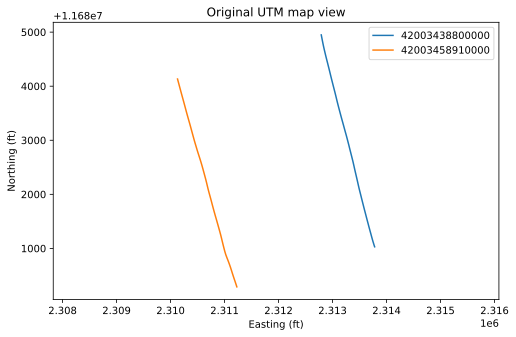

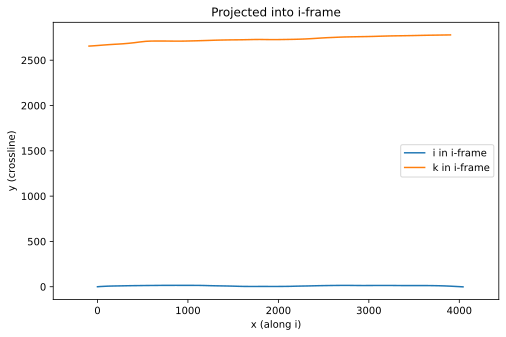

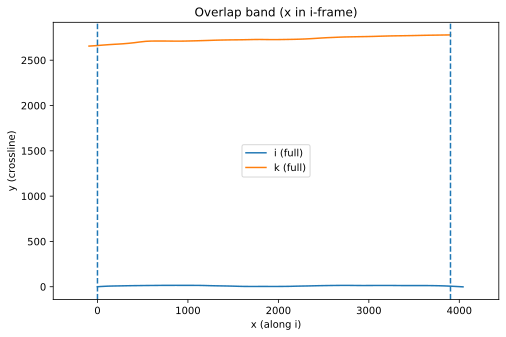

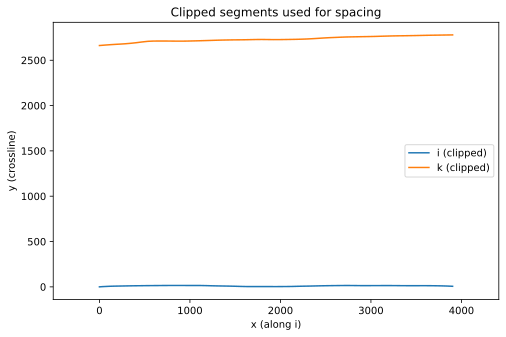

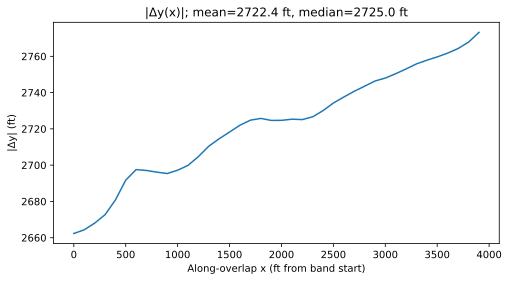

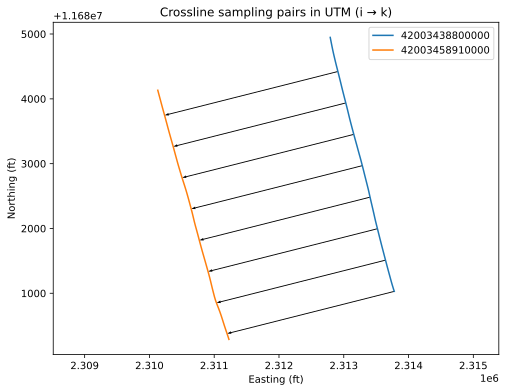

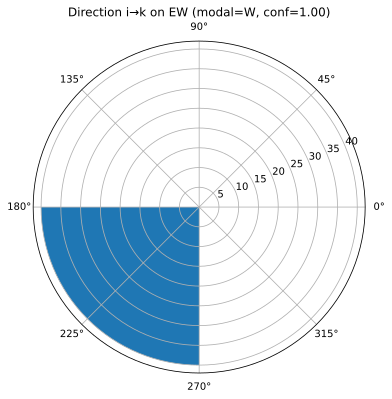

{'pair_alignment': 'parallel_like',
 'angle_deg': 1.545781267526869,
 'horizontal_dist': 2722.3958642648777,
 'horizontal_dist_median': 2724.9745326676784,
 'vertical_dist': 7.497000000000298,
 '3D_dist': 2722.4061869558536,
 'overlap_len_common_ft': 3903.22009566007,
 'LL_i': 4042.12682804037,
 'LL_k': 3999.5637313165557,
 'overlap_pct_i': 0.9656352365253115,
 'overlap_pct_k': 0.9759114638173869,
 'n_samples': 40,
 'dy_p5': 2667.828248099729,
 'min_distance_ft': nan,
 'mean_windowed_ft': nan,
 'direction_axis': 'EW',
 'direction_to_k_from_i_axis': 'W',
 'direction_axis_confidence': 1.0,
 'direction_axis_distribution': 'E:0.00,W:1.00',
 'paths': {}}

In [26]:
spacing_stats_ik.debug_pair_spacing(
    uwi_i="42003438800000",
    uwi_k="42003458910000"
)

## 5. Get OneLine

In [ ]:
class DirectionalBenchNeighbors:
    """
    Summarize nearest neighbors per well_i by bench and opposite direction.

    For each well_i, produce:
      - SAME-bench closest (any direction, or axis-limited) -> *_same_1
      - SAME-bench closest in the OPPOSITE direction of same_1 -> *_same_2
      - DIFFERENT-bench closest (any direction, or axis-limited) -> *_near_1
      - DIFFERENT-bench closest in the OPPOSITE direction of near_1 -> *_near_2

    Required columns
    ----------------
    spacing_df:
        'well_i', 'well_k', 'horizontal_dist', 'vertical_dist', '3D_dist',
        'direction_to_k_from_i_axis', 'overlap_pct_k'
        # overlap_pct_k is only required if overlap_pct_k_min is provided.
    header_df:
        'uwi', 'bench'

    Parameters (at call-time)
    -------------------------
    cutoff_ft : float
        Horizontal cutoff distance (feet).
    vertical_cutoff_ft : float, optional
        If provided, also require vertical_dist <= vertical_cutoff_ft.
        If None, no vertical filter is applied.
    axis_mode : {'any', 'EW', 'NS'}, default 'any'
        If 'EW', only E/W directions are eligible for the *_1 pick.
        If 'NS', only N/S directions are eligible for the *_1 pick.
        If 'any', all four directions can compete for *_1.
    prefer_axis : {'EW', 'NS'} | None, default None
        If set and there is a tie in horizontal distance for *_1 across axes,
        prefer the candidate whose direction belongs to that axis family.
    overlap_pct_k_min : float, optional
        If provided, require that overlap_pct_k >= this value for a pair
        to be considered. This ensures that well_k overlaps well_i by at
        least the given percentage of k’s own lateral length.

    Output columns
    --------------
      uwi_same_1,  hz_ft_to_same_1,  vt_ft_to_same_1,  3d_ft_to_same_1,
      uwi_same_2,  hz_ft_to_same_2,  vt_ft_to_same_2,  3d_ft_to_same_2,
      uwi_near_1,  hz_ft_to_near_1,  vt_ft_to_near_1,  3d_ft_to_near_1,
      uwi_near_2,  hz_ft_to_near_2,  vt_ft_to_near_2,  3d_ft_to_near_2

    Examples
    --------
    >>> nb = DirectionalBenchNeighbors()

    # Example 1: horizontal cutoff only
    >>> out1 = nb.summarize(spacing_df, header_df, cutoff_ft=1320.0)
    >>> out1.filter(regex="^uwi_|^hz_ft_").head()

    # Example 2: add vertical cutoff of 200 ft
    >>> out2 = nb.summarize(spacing_df, header_df,
    ...                     cutoff_ft=1320.0, vertical_cutoff_ft=200.0)

    # Example 3: restrict initial pick to EW directions only
    >>> out3 = nb.summarize(spacing_df, header_df,
    ...                     cutoff_ft=1320.0, axis_mode="EW")

    # Example 4: allow any axis but prefer NS in case of ties
    >>> out4 = nb.summarize(spacing_df, header_df,
    ...                     cutoff_ft=1320.0, axis_mode="any", prefer_axis="NS")

    # Example 5: require at least 80% overlap of k relative to i
    >>> out5 = nb.summarize(spacing_df, header_df,
    ...                     cutoff_ft=1320.0, overlap_pct_k_min=0.80)
    """

    # --- Type aliases inside the class ---
    Direction = Literal["E", "W", "N", "S"]
    AxisMode = Literal["any", "EW", "NS"]
    AxisPref = Literal["EW", "NS"]

    _OPPOSITE: Dict[Direction, Direction] = {"E": "W", "W": "E", "N": "S", "S": "N"}

    def __init__(self, *, tie_break_on: str = "well_k") -> None:
        """
        Parameters
        ----------
        tie_break_on : str, default 'well_k'
            Secondary stable key when distances tie.
        """
        self.tie_break_on = tie_break_on

    # ---------- Public API ----------

    def summarize(
        self,
        spacing_df: pd.DataFrame,
        header_df: pd.DataFrame,
        *,
        cutoff_ft: float,
        vertical_cutoff_ft: Optional[float] = None,
        axis_mode: AxisMode = "any",
        prefer_axis: Optional[AxisPref] = None,
        overlap_pct_k_min: Optional[float] = None,  # <-- NEW
    ) -> pd.DataFrame:
        self._validate_inputs(spacing_df, header_df)
        """Return one summary row per well_i with *_same_{1,2} and *_near_{1,2}.

        See class docstring for details on behavior and examples.

        Raises
        ------
        ValueError
            If required columns are missing or inputs are inconsistent.
        """
        # Normalize IDs to strings
        spacing = spacing_df.copy()
        spacing["well_i"] = spacing["well_i"].astype(str)
        spacing["well_k"] = spacing["well_k"].astype(str)
        header = header_df.copy()
        header["uwi"] = header["uwi"].astype(str)

        # Map benches
        bench_map = header.set_index("uwi")["bench"]
        spacing["bench_i"] = spacing["well_i"].map(bench_map)
        spacing["bench_k"] = spacing["well_k"].map(bench_map)

        # --- Apply cutoffs ---
        mask = spacing["horizontal_dist"] <= cutoff_ft
        if vertical_cutoff_ft is not None:
            mask &= spacing["vertical_dist"] <= vertical_cutoff_ft

        # NEW: optional overlap filter on k
        if overlap_pct_k_min is not None:
            if "overlap_pct_k" not in spacing.columns:
                raise ValueError(
                    "spacing_df missing required column 'overlap_pct_k' when overlap_pct_k_min is provided."
                )
            mask &= spacing["overlap_pct_k"] >= overlap_pct_k_min

        spacing = spacing.loc[mask].copy()

        if spacing.empty:
            wells = spacing_df["well_i"].astype(str).unique()
            return self._empty_summary(wells)

        # SAME vs NEAR
        spacing["is_same"] = spacing["bench_i"] == spacing["bench_k"]
        same = spacing.loc[spacing["is_same"]].copy()
        near = spacing.loc[~spacing["is_same"]].copy()

        same_summary = self._compute_category_summary(
            same, category="same", axis_mode=axis_mode, prefer_axis=prefer_axis
        )
        near_summary = self._compute_category_summary(
            near, category="near", axis_mode=axis_mode, prefer_axis=prefer_axis
        )

        all_wells = spacing_df["well_i"].astype(str).drop_duplicates().to_frame(name="well_i")
        out = (
            all_wells.merge(same_summary, on="well_i", how="left")
                     .merge(near_summary, on="well_i", how="left")
        )

        ordered_cols = (
            ["well_i"]
            + self._category_cols("same", 1)
            + self._category_cols("same", 2)
            + self._category_cols("near", 1)
            + self._category_cols("near", 2)
        )
        existing_cols = [c for c in ordered_cols if c in out.columns]
        return out[existing_cols + [c for c in out.columns if c not in existing_cols]]
    
    # ---------- Internals: category computation ----------

    def _compute_category_summary(
        self,
        df: pd.DataFrame,
        *,
        category: Literal["same", "near"],
        axis_mode: AxisMode,
        prefer_axis: Optional[AxisPref],
    ) -> pd.DataFrame:
        """
        Build a summary for one category (same/near) using vectorized reductions.

          1) Best-per-direction (well_i, direction) by horizontal_dist
             (tie-break: well_k for determinism).
          2) *_1: among eligible directions (based on axis_mode), pick best overall.
             If `prefer_axis` is set, bias ties toward that axis family.
          3) *_2: pick best entry in the opposite direction of *_1 (if exists).

        Returns
        -------
        pd.DataFrame with:
          ['well_i'] + uwi_{cat}_1, hz_ft_to_{cat}_1, vt_ft_to_{cat}_1, 3d_ft_to_{cat}_1,
                       uwi_{cat}_2, hz_ft_to_{cat}_2, vt_ft_to_{cat}_2, 3d_ft_to_{cat}_2
        """
        if df.empty:
            return pd.DataFrame(columns=["well_i"] + self._category_cols(category, 1) + self._category_cols(category, 2))

        # Step 1: best per-direction (argmin via sort + drop_duplicates)
        per_dir = (
            df.assign(direction=df["direction_to_k_from_i_axis"])
              .sort_values(["well_i", "direction", "horizontal_dist", self.tie_break_on])
              .drop_duplicates(subset=["well_i", "direction"], keep="first")
              .loc[:, ["well_i", "direction", "well_k", "horizontal_dist", "vertical_dist", "3D_dist"]]
        )

        if per_dir.empty:
            return pd.DataFrame(columns=["well_i"] + self._category_cols(category, 1) + self._category_cols(category, 2))

        # Eligible directions for *_1 based on axis_mode
        if axis_mode == "EW":
            eligible = {"E", "W"}
        elif axis_mode == "NS":
            eligible = {"N", "S"}
        else:
            eligible = {"E", "W", "N", "S"}

        per_dir_eligible = per_dir.loc[per_dir["direction"].isin(eligible)].copy()
        if per_dir_eligible.empty:
            # No eligible directions for *_1 => no *_1 and consequently no *_2
            return pd.DataFrame({"well_i": per_dir["well_i"].unique()}).astype({"well_i": str})

        # Step 2: choose *_1 across eligible directions with optional axis preference
        if prefer_axis is None:
            # Pure distance, then well_k
            best_overall = (
                per_dir_eligible.sort_values(["well_i", "horizontal_dist", "well_k"])
                                .drop_duplicates(subset=["well_i"], keep="first")
            )
        else:
            prefer_set = {"E", "W"} if prefer_axis == "EW" else {"N", "S"}
            # Priority 0 if in preferred axis family; 1 otherwise
            per_dir_eligible = per_dir_eligible.assign(
                _axis_priority=np.where(per_dir_eligible["direction"].isin(prefer_set), 0, 1)
            )
            best_overall = (
                per_dir_eligible.sort_values(["well_i", "horizontal_dist", "_axis_priority", "well_k"])
                                .drop_duplicates(subset=["well_i"], keep="first")
            )

        best_overall = best_overall.rename(columns={
            "well_k": f"uwi_{category}_1",
            "horizontal_dist": f"hz_ft_to_{category}_1",
            "vertical_dist": f"vt_ft_to_{category}_1",
            "3D_dist": f"3d_ft_to_{category}_1",
            "direction": f"direction_{category}_1",
        })

        keep_cols_1 = ["well_i",
                       f"uwi_{category}_1",
                       f"hz_ft_to_{category}_1",
                       f"vt_ft_to_{category}_1",
                       f"3d_ft_to_{category}_1",
                       f"direction_{category}_1"]
        best_overall = best_overall.loc[:, keep_cols_1]

        if best_overall.empty:
            return best_overall.drop(columns=[f"direction_{category}_1"], errors="ignore")

        # Step 3: *_2 is best in the opposite direction of *_1 (if present)
        best_overall = best_overall.copy()
        best_overall[f"opp_dir_{category}"] = best_overall[f"direction_{category}_1"].map(self._OPPOSITE)

        # Build lookup for opposite-direction minima (from all per_dir, not just eligible)
        per_dir_for_merge = per_dir.rename(columns={
            "direction": f"opp_dir_{category}",
            "well_k": f"uwi_{category}_2",
            "horizontal_dist": f"hz_ft_to_{category}_2",
            "vertical_dist": f"vt_ft_to_{category}_2",
            "3D_dist": f"3d_ft_to_{category}_2",
        })

        merged = best_overall.merge(
            per_dir_for_merge[["well_i",
                               f"opp_dir_{category}",
                               f"uwi_{category}_2",
                               f"hz_ft_to_{category}_2",
                               f"vt_ft_to_{category}_2",
                               f"3d_ft_to_{category}_2"]],
            on=["well_i", f"opp_dir_{category}"],
            how="left",
        )

        return merged.drop(columns=[f"direction_{category}_1", f"opp_dir_{category}"])

    # ---------- Internals: utilities ----------

    @staticmethod
    def _category_cols(cat: Literal["same", "near"], idx: Literal[1, 2]) -> List[str]:
        return [
            f"uwi_{cat}_{idx}",
            f"hz_ft_to_{cat}_{idx}",
            f"vt_ft_to_{cat}_{idx}",
            f"3d_ft_to_{cat}_{idx}",
        ]

    @staticmethod
    def _empty_summary(wells: Iterable[str]) -> pd.DataFrame:
        cols = ["well_i"]
        for cat in ("same", "near"):
            for idx in (1, 2):
                cols += [
                    f"uwi_{cat}_{idx}",
                    f"hz_ft_to_{cat}_{idx}",
                    f"vt_ft_to_{cat}_{idx}",
                    f"3d_ft_to_{cat}_{idx}",
                ]
        out = pd.DataFrame({"well_i": list(map(str, wells))})
        for c in cols:
            if c != "well_i":
                out[c] = np.nan
        return out

    @staticmethod
    def _validate_inputs(spacing_df: pd.DataFrame, header_df: pd.DataFrame) -> None:
        spacing_required = {
            "well_i",
            "well_k",
            "horizontal_dist",
            "vertical_dist",
            "3D_dist",
            "direction_to_k_from_i_axis",
        }
        header_required = {"uwi", "bench"}

        missing_s = spacing_required - set(spacing_df.columns)
        missing_h = header_required - set(header_df.columns)
        if missing_s:
            raise ValueError(f"spacing_df missing required columns: {sorted(missing_s)}")
        if missing_h:
            raise ValueError(f"header_df missing required columns: {sorted(missing_h)}")

### 5.1 Joining bench with spacing ik dataframe

In [ ]:
df_spacing_ik_bench = df_spacing_ik.copy()

bench_map = df_header_filter.set_index("uwi")["bench"]

df_spacing_ik_bench["bench_i"] = df_spacing_ik_bench["well_i"].map(bench_map)
df_spacing_ik_bench["bench_k"] = df_spacing_ik_bench["well_k"].map(bench_map)

df_spacing_ik_bench = reorder_columns(df=df_spacing_ik_bench, columns_to_move=['bench_i', 'bench_k'], reference_column='well_k')
df_spacing_ik_bench = reorder_columns(df=df_spacing_ik_bench, 
                                        columns_to_move=['direction_to_k_from_i_axis','overlap_pct_i', 'overlap_pct_k','overlap_len_common_ft', 'LL_i', 'LL_k'], 
                                        reference_column='3D_dist')

### 5.2 Running oneline

In [ ]:
# Filter out rows where 'reject_reason' is not empty
df_spacing_ik_bench_filt = df_spacing_ik_bench[df_spacing_ik_bench["reject_reason"]==""].reset_index(drop=True).copy()

In [ ]:
nb = DirectionalBenchNeighbors()

# A) Classic: 1320′ cutoff, any axis, no preference
res_any = nb.summarize(spacing_df=df_spacing_ik_bench_filt, header_df=df_header_filter, 
                       cutoff_ft=1800.0, vertical_cutoff_ft=150.00, 
                       overlap_pct_k_min=0.30)   # require ≥30% of k overlaps with i

# B) Only EW is eligible for *_1, and prefer EW if ties occur
res_ew = nb.summarize(spacing_df=df_spacing_ik_bench_filt, header_df=df_header_filter, 
                      cutoff_ft=1800.0, vertical_cutoff_ft=150.00, overlap_pct_k_min=0.30, # require ≥30% of k overlaps with i
                      axis_mode="EW", prefer_axis="EW")

# C) Any axis is eligible for *_1, but prefer NS on distance ties
res_any_pref_ns = nb.summarize(spacing_df=df_spacing_ik_bench_filt, header_df=df_header_filter, 
                               cutoff_ft=1800.0, vertical_cutoff_ft=150.00, overlap_pct_k_min=0.30, # require ≥30% of k overlaps with i
                               axis_mode="any", prefer_axis="NS")